#AI-Powered E-Commerce Analytics Platform

######A key feature of the platform is the integration of Generative AI, which automatically summarizes business performance, generates executive reports, explains dashboard insights in natural language, and provides an AI-powered chatbot that allows users to interact with business data using conversational queries. This enables non-technical users to access complex analytics through simple questions and receive intelligent recommendations.

Develop an intelligent e-commerce analytics platform that enables business owners to Monitor business performance through interactive dashboards,
Predict future sales using AI models, Understand customer satisfaction,
Recommend products to customers, Generate AI-driven business insights and reports, Interact with business data using natural language.


##Import and install all necessary libraries and  

In [1]:
!pip install pmdarima
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
from scipy.stats import skew,kurtosis
import datetime as dt
import calendar
from matplotlib.gridspec import GridSpec
pd.set_option('display.max_columns', 100)
import plotly.offline as py
import plotly.express as px
import plotly.graph_objs as go
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import math
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import root_mean_squared_log_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import r2_score

from prophet import Prophet
from pmdarima import auto_arima
import time
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 15.3 MB/s eta 0:00:00


##Load dataset

In [2]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/olist_master_dataset.csv')

In [3]:
#copy original data for preprocessing
df=data.copy()

##Data understanding

In [4]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto


In [5]:
df.shape

(119143, 37)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

In [7]:
#Convert all date columns
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [8]:
df[date_columns].dtypes

,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]
shipping_limit_date,datetime64[ns]
review_creation_date,datetime64[ns]
review_answer_timestamp,datetime64[ns]


In [9]:
#Statistical summary (Numerical)
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,order_item_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_installments,payment_value,review_score,review_creation_date,review_answer_timestamp
count,119143,118966,117057,115722,119143,119143.000000,118310.000000,118310,118310.000000,118310.000000,116601.000000,116601.000000,116601.000000,118290.000000,118290.000000,118290.000000,118290.000000,119140.000000,119140.000000,119140.000000,118146.000000,118146,118146
mean,2017-12-29 18:36:13.115760128,2017-12-30 04:49:18.425726976,2018-01-03 08:24:34.395524864,2018-01-12 20:55:38.199616,2018-01-22 15:21:10.241642240,35033.451298,1.196543,2018-01-05 22:06:13.308807424,120.646603,20.032387,48.767498,785.967822,2.205161,2112.250740,30.265145,16.619706,23.074799,1.094737,2.941246,172.735135,4.015582,2018-01-11 13:17:50.103092992,2018-01-14 17:00:35.769302784
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1003.000000,1.000000,2016-09-19 00:15:34,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1.000000,0.000000,0.000000,1.000000,2016-10-02 00:00:00,2016-10-07 18:32:28
25%,2017-09-10 20:15:46,2017-09-11 15:50:48.500000,2017-09-14 19:52:12,2017-09-22 21:54:31.249999872,2017-10-02 00:00:00,11250.000000,1.000000,2017-09-18 14:30:33,39.900000,13.080000,42.000000,346.000000,1.000000,300.000000,18.000000,8.000000,15.000000,1.000000,1.000000,60.850000,4.000000,2017-09-22 00:00:00,2017-09-25 11:15:40.750000128
50%,2018-01-17 11:59:12,2018-01-17 16:49:49,2018-01-23 17:03:08,2018-02-01 03:17:55,2018-02-14 00:00:00,24240.000000,1.000000,2018-01-25 04:11:15.500000,74.900000,16.280000,52.000000,600.000000,1.000000,700.000000,25.000000,13.000000,20.000000,1.000000,2.000000,108.160000,5.000000,2018-02-01 00:00:00,2018-02-03 12:04:23
75%,2018-05-03 13:18:30,2018-05-03 16:56:53,2018-05-07 14:57:00,2018-05-15 00:08:31.500000,2018-05-25 00:00:00,58475.000000,1.000000,2018-05-10 02:51:40.249999872,134.900000,21.180000,57.000000,983.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,1.000000,4.000000,189.240000,5.000000,2018-05-15 00:00:00,2018-05-17 10:48:59
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,99990.000000,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,29.000000,24.000000,13664.080000,5.000000,2018-08-31 00:00:00,2018-10-29 12:27:35
std,NaN,NaN,NaN,NaN,NaN,29823.198969,0.699489,NaN,184.109691,15.836850,10.033540,652.584121,1.717452,3786.695111,16.189367,13.453584,11.749139,0.730141,2.777848,267.776077,1.400436,NaN,NaN


In [10]:
#Statistical summary (Categorical)
df.describe(include='object')

,order_id,customer_id,order_status,customer_unique_id,customer_city,customer_state,product_id,seller_id,product_category_name,payment_type,review_id,review_comment_title,review_comment_message,product_category_name_english
count,119143,119143,119143,119143,119143,119143,118310,118310,116601,119140,118146,13989,50245,116576
unique,99441,99441,8,96096,4119,27,32951,3095,73,5,98410,4527,36159,71
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,9a736b248f67d166d2fbb006bcb877c3,sao paulo,SP,aca2eb7d00ea1a7b8ebd4e68314663af,4a3ca9315b744ce9f8e9374361493884,cama_mesa_banho,credit_card,eef5dbca8d37dfce6db7d7b16dd0525e,Recomendo,Muito bom,bed_bath_table
freq,63,63,115723,75,18875,50265,536,2155,11988,87776,63,494,259,11988


##EDA(Exploratory Data Analysis)
Objective -Discover patterns, trends, and anomalies in the data.

In [11]:
df.nunique()

,0
order_id,99441
customer_id,99441
order_status,8
order_purchase_timestamp,98875
order_approved_at,90733
order_delivered_carrier_date,81018
order_delivered_customer_date,95664
order_estimated_delivery_date,459
customer_unique_id,96096
customer_zip_code_prefix,14994


In [12]:
df.order_status.unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [13]:
df.payment_type.unique()

array(['credit_card', 'voucher', 'boleto', 'debit_card', 'not_defined',
       nan], dtype=object)

In [14]:
df.review_score.unique()

array([ 4.,  5.,  2.,  1., nan,  3.])

In [15]:
df.customer_state.unique()

array(['SP', 'BA', 'GO', 'RN', 'PR', 'RS', 'RJ', 'MG', 'SC', 'RR', 'PE',
       'TO', 'CE', 'DF', 'SE', 'MT', 'PB', 'PA', 'RO', 'ES', 'AP', 'MS',
       'MA', 'PI', 'AL', 'AC', 'AM'], dtype=object)

In [16]:
payment_methods =df['payment_type'].value_counts()
payment_methods

,count
payment_type,
credit_card,87776
boleto,23190
voucher,6465
debit_card,1706
not_defined,3


In [17]:
df['order_status'].value_counts()

,count
order_status,
delivered,115723
shipped,1256
canceled,750
unavailable,652
invoiced,378
processing,376
created,5
approved,3


In [18]:
#Top 10 states with the highest number of customers
top_states=df['customer_state'].value_counts().head(10)
top_states

,count
customer_state,
SP,50265
RJ,15518
MG,13819
RS,6573
PR,6043
SC,4345
BA,4091
DF,2516
GO,2466


In [19]:
num_cols = [
    "price",
    "freight_value",
    "payment_value",
    "payment_installments",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "product_description_lenght",
    "review_score"
   ]

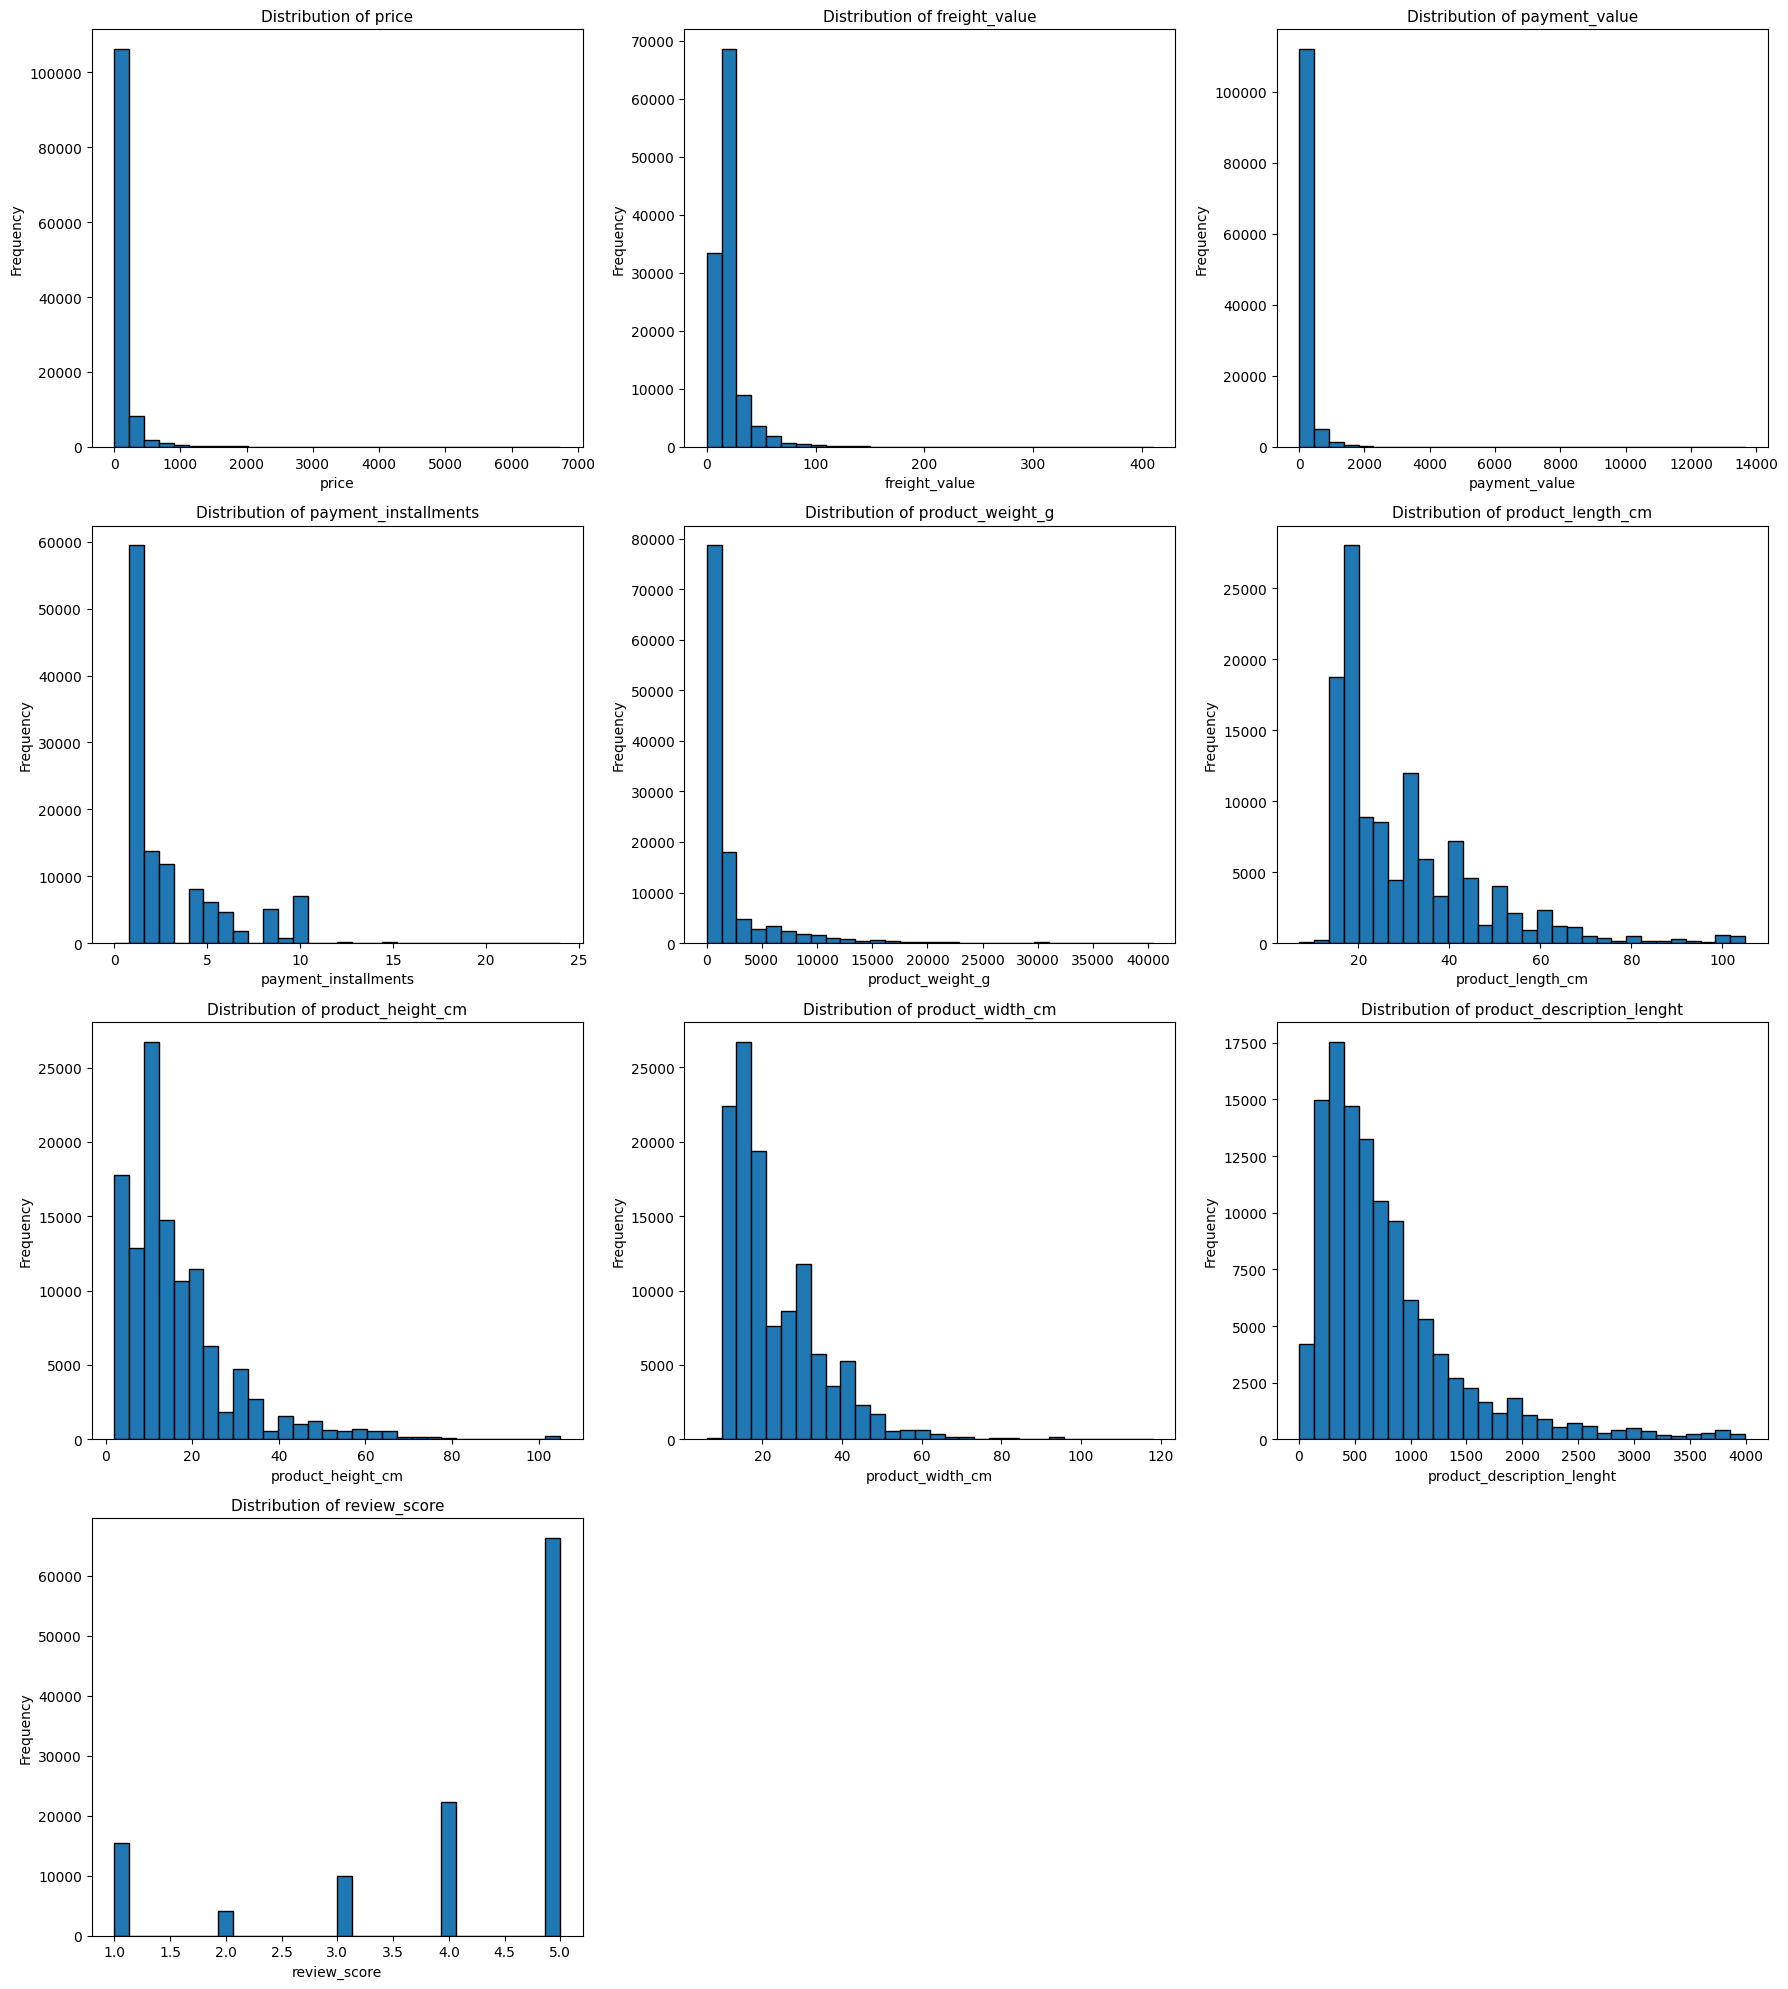

In [20]:
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.ravel()   # Flatten the axes array

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(f"Distribution of {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
cat_cols = [
    "order_status",
    "payment_type",
    "customer_state"

]

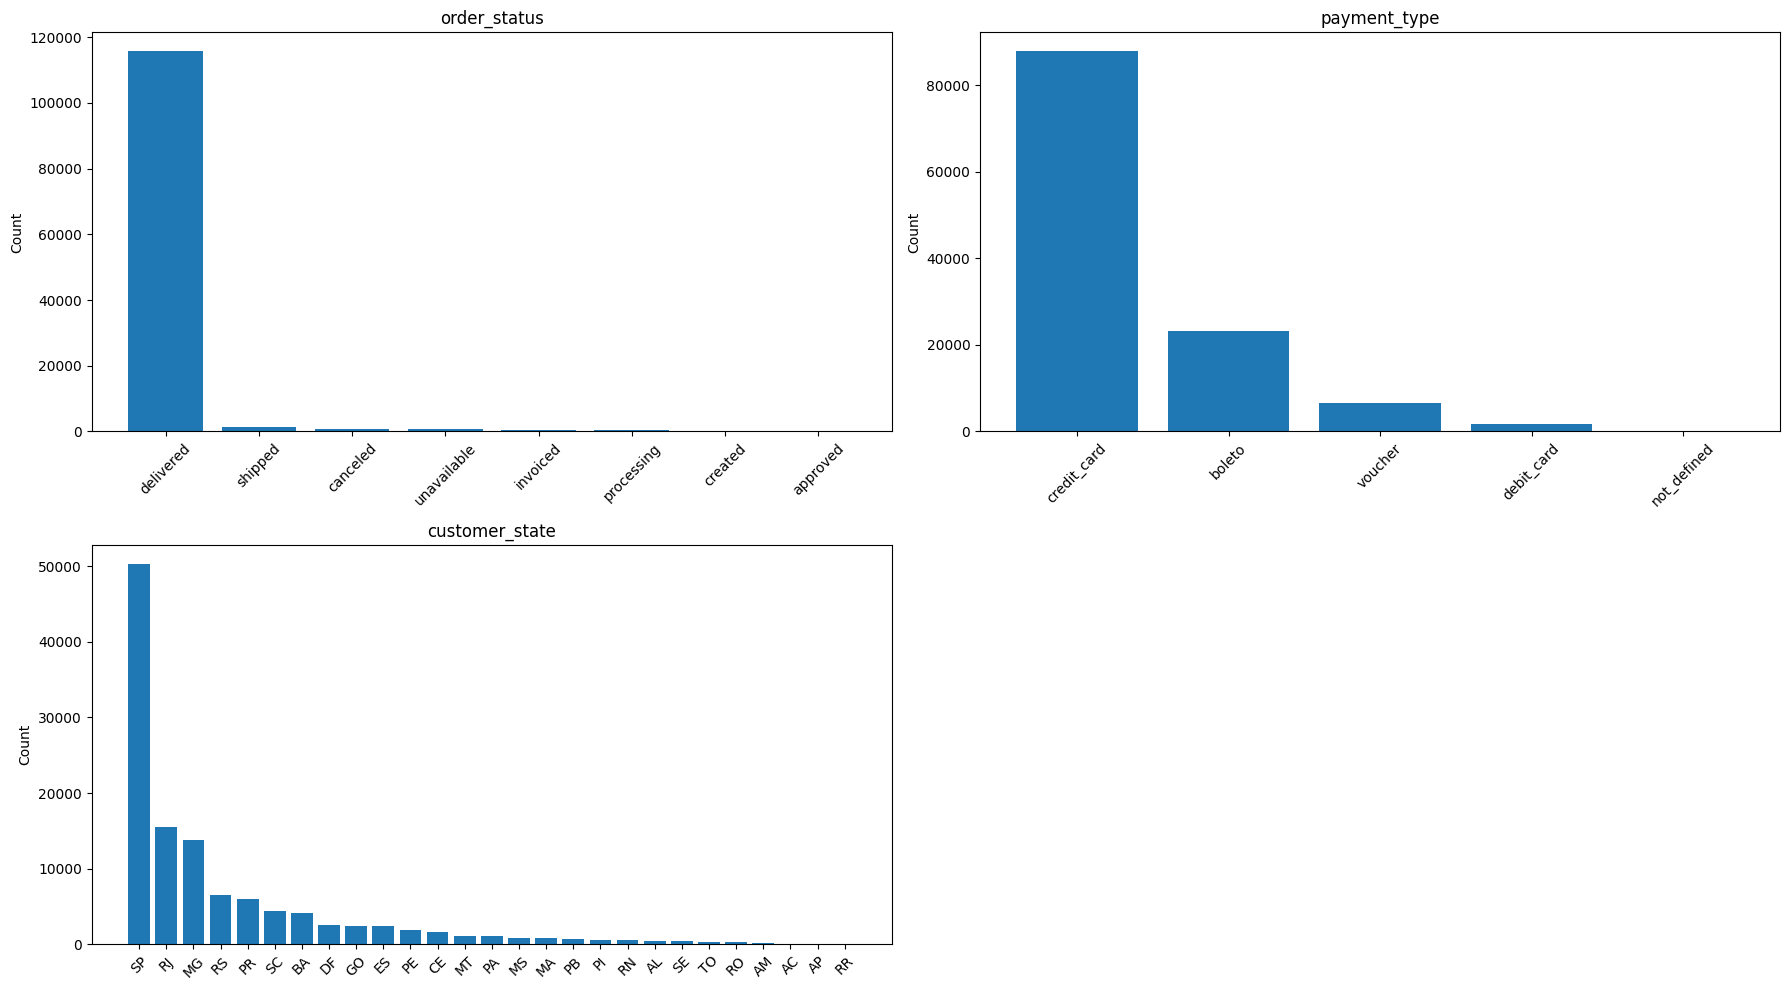

In [22]:
n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    counts = df[col].value_counts()

    axes[i].bar(counts.index.astype(str), counts.values)

    axes[i].set_title(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

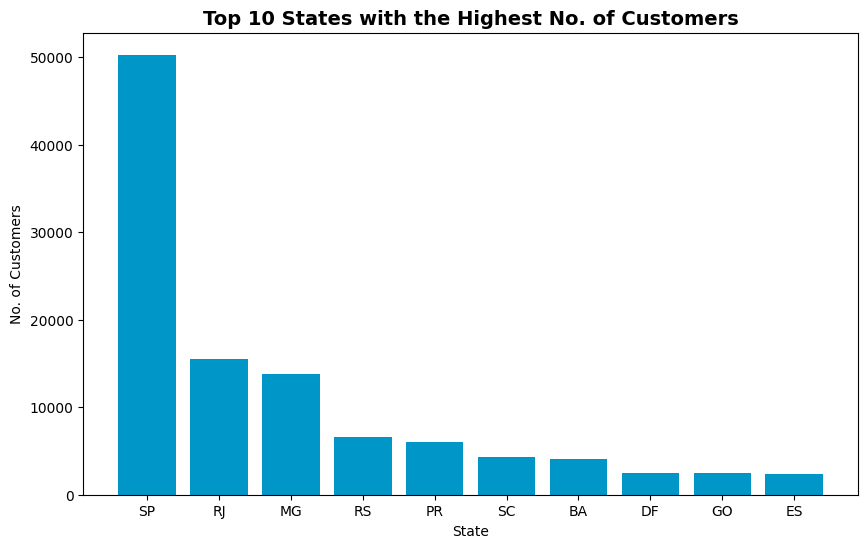

In [23]:
plt.figure(figsize=(10,6))
plt.bar(top_states.index, top_states.values,color='#0096c7')
plt.xticks(rotation=0)
plt.title('Top 10 States with the Highest No. of Customers', fontsize= 14,fontweight= 'bold')
plt.xlabel('State')
plt.ylabel('No. of Customers')
plt.show()

In [24]:
items_per_customer_order = df.groupby(['customer_unique_id', 'order_id'])['order_item_id'].count().reset_index()
items_per_customer_order.rename(columns={'order_item_id': 'num_items_in_order'}, inplace=True)

print("Top 10 customers with the most items in a single order:")
display(items_per_customer_order.sort_values(by='num_items_in_order', ascending=False).head(10))

Top 10 customers with the most items in a single order:


,customer_unique_id,order_id,num_items_in_order
60071,9a736b248f67d166d2fbb006bcb877c3,895ab968e7bb0d5659d16cd74cd1650c,63
43465,6fbc7cdadbb522125f4b27ae9dee4060,fedcd9f7ccdc8cba3a18defedd1a5547,38
53977,8af7ac63b2efbcbd88e5b11505e8098a,fa65dad1b0e818e3ccc5cb0e39231352,29
33691,569aa12b73b5f7edeaa6f2a01603e381,ccf804e764ed5650cd8759557269dc13,26
51933,85963fd37bfd387aa6d915d8a1065486,465c2e1bee4561cb39e0db8c5993aafc,24
85244,db1af3fd6b23ac3873ef02619d548f9c,68986e4324f6a21481df4e6e89abcf01,24
56101,90807fdb59eec2152bc977feeb6e47e7,6d58638e32674bebee793a47ac4cbadc,24
32699,5419a7c9b86a43d8140e2939cd2c2f7e,a3725dfe487d359b5be08cac48b64ec5,24
97056,f9ae226291893fda10af7965268fb7f6,c6492b842ac190db807c15aff21a7dd6,24
84572,d97b3cfb22b0d6b25ac9ed4e9c2d481b,5a3b1c29a49756e75f1ef513383c0c12,22


###Sales/Revenue Analysis

In [25]:
#Total Revenue
total_revenue=df['payment_value'].sum()
total_revenue

np.float64(20579664.01)

In [26]:
#Total orders
total_orders=df['order_id'].nunique()
total_orders

99441

In [27]:
# Average Order Value
avg_order_value=total_revenue / total_orders
avg_order_value

np.float64(206.9535102221418)

In [28]:
#Total unique customers
df['customer_unique_id'].nunique()

96096

In [29]:
#Total Sellers
total_sellers=df['seller_id'].nunique()
total_sellers

3095

In [30]:
#Delivery Success Rate
delivery_success_rate = ((df['order_status'] == 'delivered').sum()/ len(df)) * 100

print(f"Delivery Success Rate: {delivery_success_rate:.2f}%")

Delivery Success Rate: 97.13%


In [31]:
#Cancellation Rate
canceled_orders = (df['order_status'] == 'canceled').sum()

cancellation_rate = (canceled_orders / total_orders) * 100

print(f"Total Orders: {total_orders}")
print(f"Canceled Orders: {canceled_orders}")
print(f"Cancellation Rate: {cancellation_rate:.2f}%")

Total Orders: 99441
Canceled Orders: 750
Cancellation Rate: 0.75%


In [32]:
#Total Freight Cost
total_freight_cost = df['freight_value'].sum()

print(f"Total Freight Cost: R$ {total_freight_cost:,.2f}")

Total Freight Cost: R$ 2,370,031.65


####Visualization


In [33]:
#Can future sales be predicted?
#Monthly Revenue
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

monthly_sales = (df.groupby(df["order_purchase_timestamp"].dt.to_period("M"))["payment_value"].sum())
monthly_sales

,payment_value
order_purchase_timestamp,
2016-09,388.47
2016-10,76559.05
2016-12,19.62
2017-01,190806.27
2017-02,351848.13
2017-03,547769.84
2017-04,512126.52
2017-05,737425.31
2017-06,613777.41


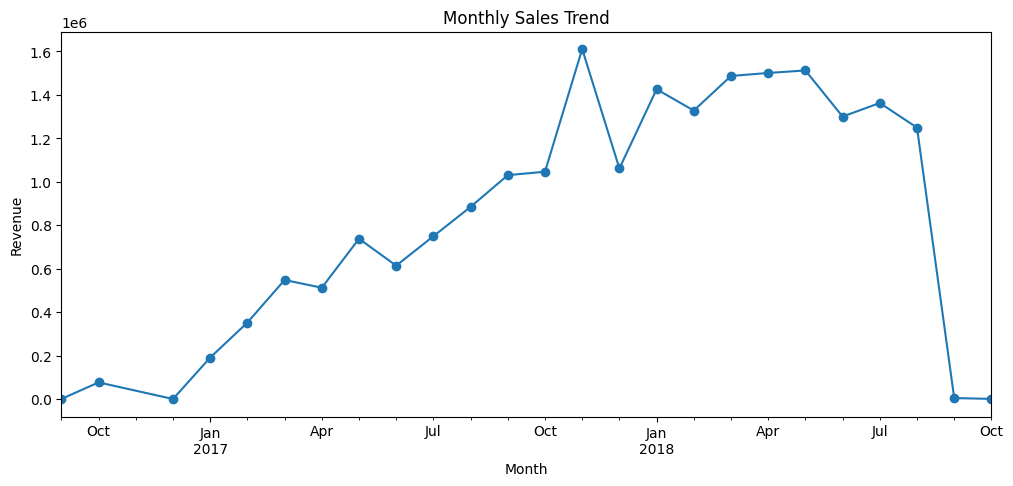

In [34]:
monthly_sales.plot(figsize=(12,5), marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [35]:
#Orders trend by month
#Monthly Orders
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

monthly_orders=(df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['order_id'].count())
monthly_orders

,order_id
order_purchase_timestamp,
2016-09,7
2016-10,401
2016-12,1
2017-01,1035
2017-02,2123
2017-03,3243
2017-04,2878
2017-05,4485
2017-06,3853


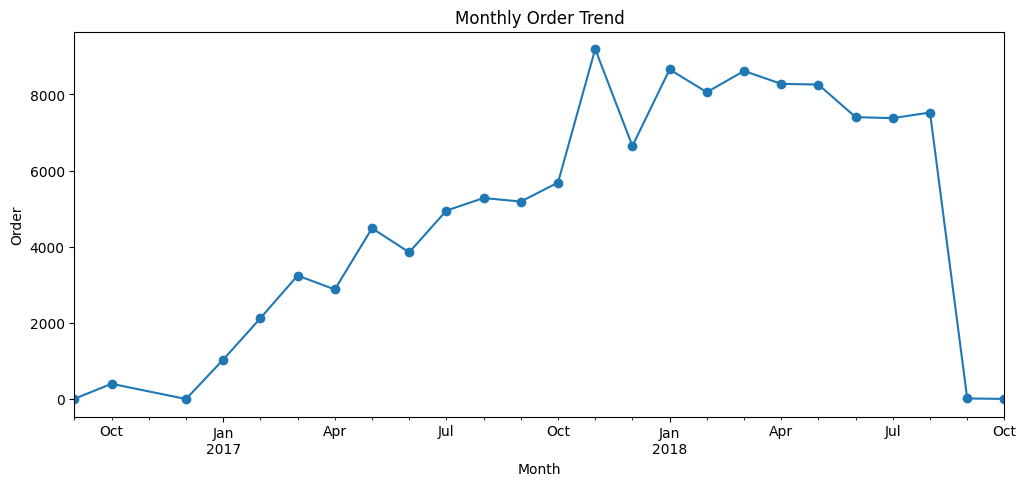

In [36]:
monthly_orders.plot(figsize=(12,5), marker="o")

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Order")
plt.show()

In [37]:
#Orders by status
# Count orders by status
status_count = (df['order_status'].value_counts().reset_index())

status_count.columns = ['order_status', 'count']

status_count

,order_status,count
0,delivered,115723
1,shipped,1256
2,canceled,750
3,unavailable,652
4,invoiced,378
5,processing,376
6,created,5
7,approved,3


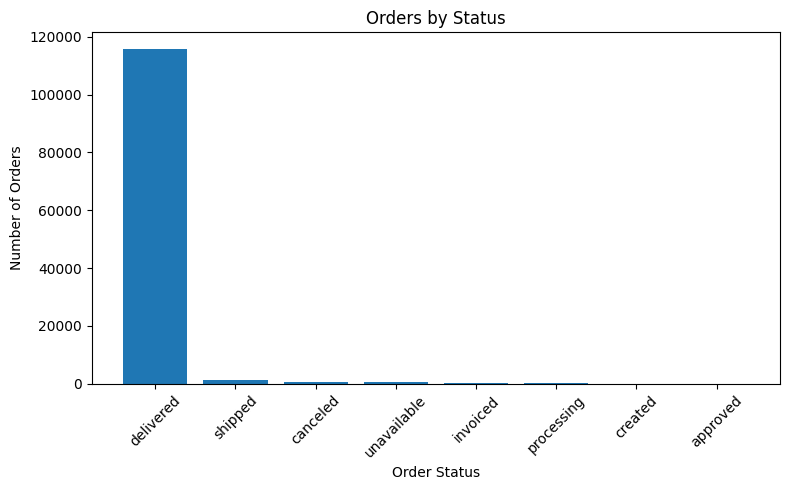

In [38]:
plt.figure(figsize=(8,5))

plt.bar(
    status_count['order_status'],
    status_count['count']
)

plt.title("Orders by Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [39]:
#Which states contribute the most revenue?
state_sales = (
    df.groupby("customer_state")["payment_value"]
      .sum()
      .sort_values(ascending=False)
)
state_sales.head(10)

,payment_value
customer_state,
SP,7726078.35
RJ,2795615.67
MG,2351221.09
RS,1160175.66
PR,1079795.49
BA,805070.98
SC,801276.45
GO,520481.65
DF,438095.32


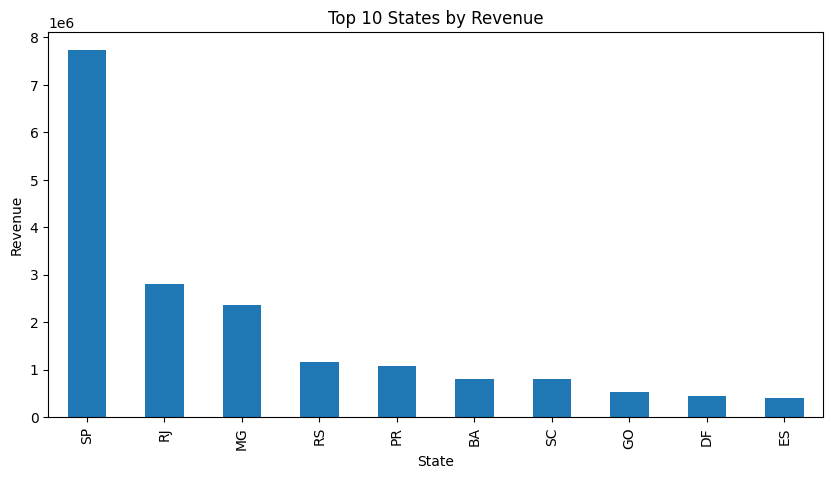

In [40]:
#Top 10 States by Revenue
state_sales.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.show()

In [41]:
#Top 10 cities with the highest number of customers
top_cities = df['customer_city'].value_counts()
print('Top 10 cities with the highest number of customers:')
top_cities.head(10)

Top 10 cities with the highest number of customers:


,count
customer_city,
sao paulo,18875
rio de janeiro,8311
belo horizonte,3299
brasilia,2500
curitiba,1827
campinas,1757
porto alegre,1675
salvador,1544
guarulhos,1415


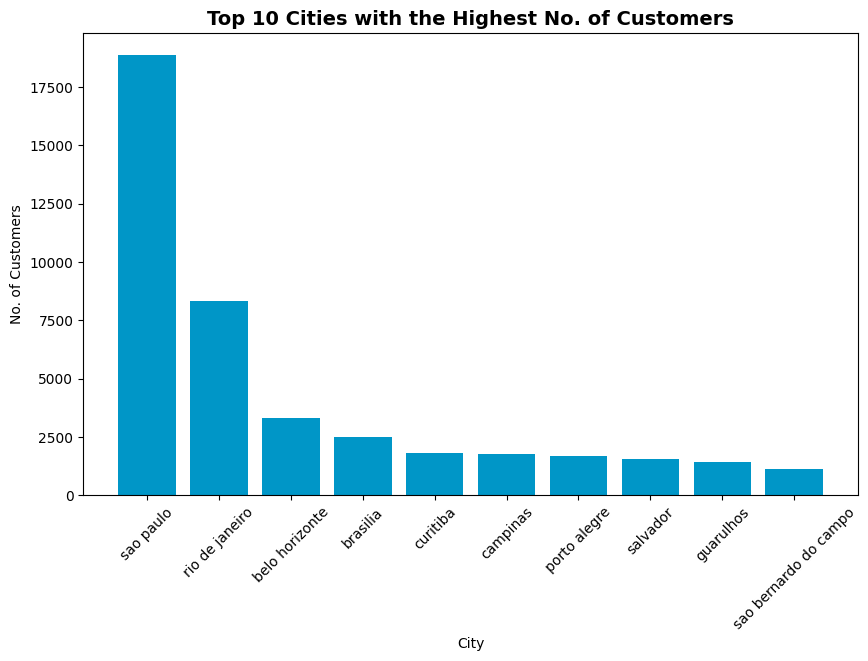

In [42]:

plt.figure(figsize=(10,6))
plt.bar(top_cities.index[:10], top_cities.values[:10],color='#0096c7')
plt.xticks(rotation=45)
plt.title('Top 10 Cities with the Highest No. of Customers',fontsize = 14 , fontweight= 'bold')
plt.xlabel('City')
plt.ylabel('No. of Customers')
plt.show()

In [43]:
#No. of Sellers
unique_categories = df['product_category_name'].nunique()
print(f"No. of Categories: {unique_categories}")
print('_'*30)
unique_sellers = df['seller_id'].nunique()
print(f"No. of Sellers: {unique_sellers}")

No. of Categories: 73
______________________________
No. of Sellers: 3095


In [44]:
product_performance = df.groupby('product_category_name_english').agg(
    total_revenue=('payment_value', 'sum'),
    total_orders=('order_item_id', 'count')
).reset_index()

# Sort by total revenue to find the top revenue-generating categories
top_revenue_products = product_performance.sort_values(by='total_revenue', ascending=False).head(10)
print('Top 10 Product Categories by Total Revenue:')
display(top_revenue_products)


Top 10 Product Categories by Total Revenue:


,product_category_name_english,total_revenue,total_orders
7,bed_bath_table,1743998.80,11988
43,health_beauty,1662963.59,10032
15,computers_accessories,1599481.06,8150
39,furniture_decor,1443963.61,8832
70,watches_gifts,1430553.48,6213
65,sports_leisure,1400223.07,9004
49,housewares,1097900.09,7380
5,auto,855095.68,4400
42,garden_tools,840721.59,4590
20,cool_stuff,781933.97,3999


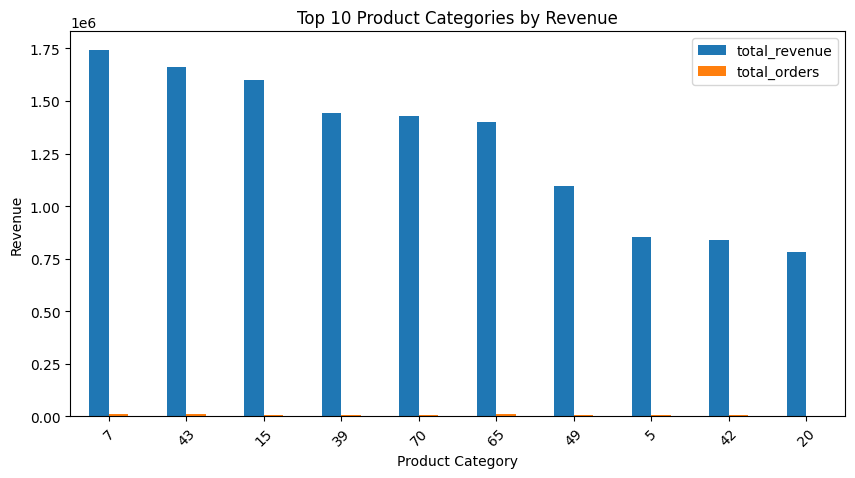

In [45]:
#Top 10 Product Categories by Revenue
top_revenue_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [46]:
top_rev_categories = df.groupby('product_category_name_english')['price'].sum().sort_index()
print('Top 10 Categories by Total Revenue:')
top_rev_categories.head(10)

Top 10 Categories by Total Revenue:


,price
product_category_name_english,
agro_industry_and_commerce,83841.95
air_conditioning,55962.38
art,24721.97
arts_and_craftmanship,1814.01
audio,52500.27
auto,618395.50
baby,434832.19
bed_bath_table,1107249.09
books_general_interest,48197.45


In [47]:
category_summary = (
    df.groupby('product_category_name_english')
    .agg(
        total_revenue=('payment_value', 'sum'),
        total_orders=('order_id', 'nunique'),
        total_price=('price', 'sum')
    )
    .reset_index()
)
category_summary.head(10)

,product_category_name_english,total_revenue,total_orders,total_price
0,agro_industry_and_commerce,118730.61,182,83841.95
1,air_conditioning,91170.66,253,55962.38
2,art,30992.93,202,24721.97
3,arts_and_craftmanship,2326.17,23,1814.01
4,audio,60388.62,350,52500.27
5,auto,855095.68,3897,618395.50
6,baby,540374.92,2885,434832.19
7,bed_bath_table,1743998.80,9417,1107249.09
8,books_general_interest,64694.76,512,48197.45
9,books_imported,6701.89,53,4851.85


In [48]:
payment_revenue = (
    df.groupby("payment_type")["payment_value"]
      .sum()
      .sort_values(ascending=False)
)

payment_revenue

,payment_value
payment_type,
credit_card,15775450.54
boleto,4110920.74
voucher,435917.84
debit_card,257374.89
not_defined,0.00


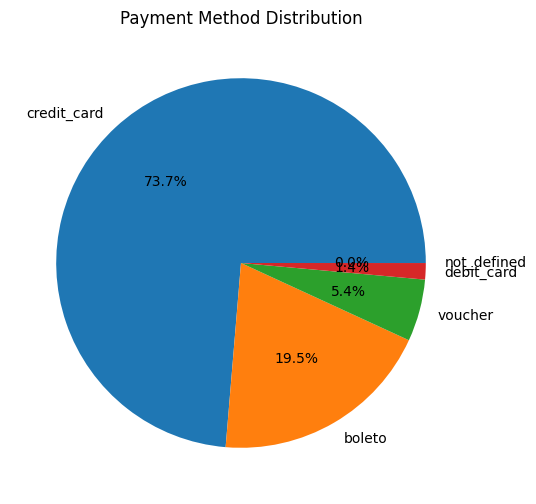

In [49]:
#Payment Method Distribution
payment_methods.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

###Sales Analytics -Analyze sales performance over time


In [50]:
# Time-based features
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month
df['quarter'] = df['order_purchase_timestamp'].dt.quarter
df['dayofweek'] = df['order_purchase_timestamp'].dt.dayofweek
df['dayofyear'] = df['order_purchase_timestamp'].dt.dayofyear
df['hour'] = df['order_purchase_timestamp'].dt.hour
df['date'] = df['order_purchase_timestamp'].dt.date
df['week'] = df['order_purchase_timestamp'].dt.isocalendar().week
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

In [51]:
#The hour that got most orders
rush_hr = (df.groupby('hour')['order_id'].nunique().reset_index(name='number_of_orders'))

rush_hr

,hour,number_of_orders
0,0,2394
1,1,1170
2,2,510
3,3,272
4,4,206
5,5,188
6,6,502
7,7,1231
8,8,2967
9,9,4785


In [52]:
def categorize_hour(hour):
    if 0 <= hour < 6:
        return "Late Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df['rush_hr'] = df['hour'].apply(categorize_hour)

In [53]:
#The hour that got most orders
rush_hr = (
    df.groupby('rush_hr')['order_id']
      .nunique()
      .reset_index(name='number_of_orders')
)

rush_hr

,rush_hr,number_of_orders
0,Afternoon,32211
1,Evening,24094
2,Late Night,4740
3,Morning,22240
4,Night,16156


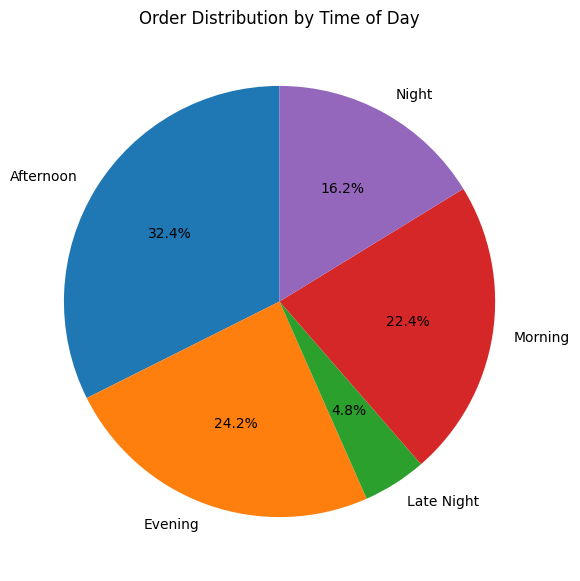

In [54]:
plt.figure(figsize=(7,7))

plt.pie(
    rush_hr['number_of_orders'],
    labels=rush_hr['rush_hr'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Order Distribution by Time of Day")
plt.show()

In [55]:
#The month that got most orders
month= df['month'].value_counts().reset_index(name='number_of_orders')
month.columns = ['month','number_of_orders']
month.head(5)

,month,number_of_orders
0,8,12802
1,5,12743
2,7,12325
3,3,11858
4,6,11256


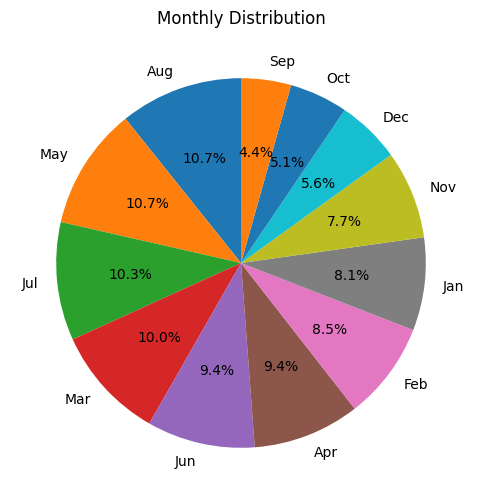

In [56]:
plt.figure(figsize=(6,6))

plt.pie(
    month['number_of_orders'],
    labels=[calendar.month_abbr[int(m)] for m in month["month"]],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Monthly Distribution")
plt.show()

In [57]:
#The year that got most orders
year= df['year'].value_counts().reset_index(name='number_of_orders')
year.columns = ['year','number_of_orders']
year.head(5)

,year,number_of_orders
0,2018,64185
1,2017,54549
2,2016,409


In [58]:
#The quarter that got most orders
quarter= df['quarter'].value_counts().reset_index(name='number_of_orders')
quarter.columns = ['quarter','number_of_orders']
quarter.head(5)

,quarter,number_of_orders
0,2,35154
1,1,31728
2,3,30336
3,4,21925


In [59]:
#The week that got most orders
week= df['week'].value_counts().reset_index(name='number_of_orders')
week.columns = ['week','number_of_orders']
week.head(5)

,week,number_of_orders
0,47,3713
1,31,3545
2,32,3537
3,33,3374
4,19,3367


In [60]:
#The week day name that got most orders
dayofweek= df['dayofweek'].value_counts().reset_index(name='number_of_orders')
dayofweek.columns = ['dayofweek','number_of_orders']
dayofweek.head(5)

,dayofweek,number_of_orders
0,0,19366
1,1,19315
2,2,18640
3,3,17826
4,4,17006


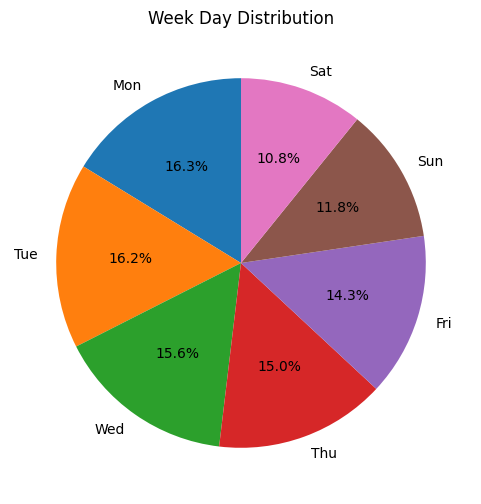

In [61]:
plt.figure(figsize=(6,6))

plt.pie(
    dayofweek['number_of_orders'],
    labels=[calendar.day_abbr[int(m)] for m in dayofweek["dayofweek"]],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Week Day Distribution")
plt.show()

In [62]:
#The is_weekend that got most orders
is_weekend= df['is_weekend'].value_counts().reset_index(name='number_of_orders')
is_weekend.columns = ['is_weekend','number_of_orders']
is_weekend.head(5)

,is_weekend,number_of_orders
0,0,92153
1,1,26990


In [63]:
#The date that got most orders
date= df['date'].value_counts().reset_index(name='number_of_orders')
date.columns = ['date','number_of_orders']
date.head(5)

,date,number_of_orders
0,2017-11-24,1435
1,2017-11-25,640
2,2017-11-27,508
3,2017-11-26,485
4,2017-11-28,453


In [64]:
#Sales comparison with previous month
monthly_sales = monthly_sales.reset_index(name='Sales')


# Previous Month Sales
monthly_sales['Previous_Month_Sales'] = monthly_sales['Sales'].shift(1)

In [65]:
# MoM Growth %(with an up/down indicator)
#This combination gives users an immediate view of whether sales are improving or declining from one month to the next.
monthly_sales['MoM_Growth_%'] = (
    (monthly_sales['Sales'] - monthly_sales['Previous_Month_Sales'])
    / monthly_sales['Previous_Month_Sales']
) * 100

monthly_sales

,order_purchase_timestamp,Sales,Previous_Month_Sales,MoM_Growth_%
0,2016-09,388.47,NaN,NaN
1,2016-10,76559.05,388.47,19607.841017
2,2016-12,19.62,76559.05,-99.974373
3,2017-01,190806.27,19.62,972409.021407
4,2017-02,351848.13,190806.27,84.400717
5,2017-03,547769.84,351848.13,55.683601
6,2017-04,512126.52,547769.84,-6.506988
7,2017-05,737425.31,512126.52,43.992799
8,2017-06,613777.41,737425.31,-16.767515
9,2017-07,749242.84,613777.41,22.070775


Daily sales data:


,ds,y
0,2016-09-04,272.46
1,2016-09-05,75.06
2,2016-09-06,0.00
3,2016-09-07,0.00
4,2016-09-08,0.00


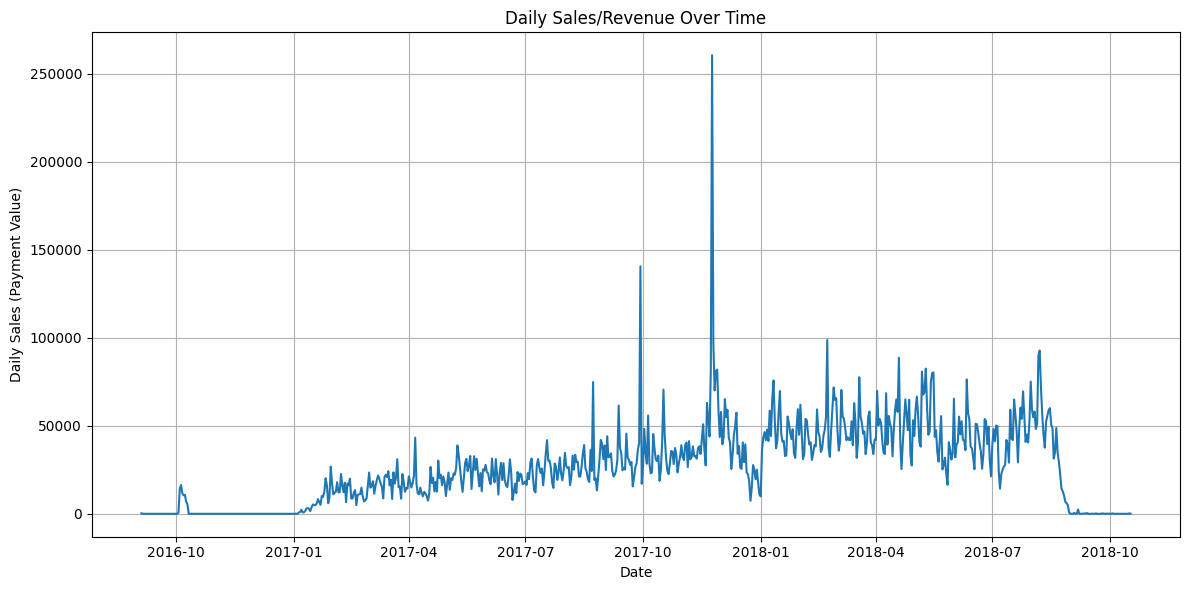

In [66]:
# Set 'order_purchase_timestamp' as the index
df_ts = df.set_index('order_purchase_timestamp')

# Resample the data to daily frequency and sum the 'payment_value'
daily_sales = df_ts['payment_value'].resample('D').sum().reset_index()

# Rename columns for Prophet compatibility (ds for date, y for value)
daily_sales.columns = ['ds', 'y']

print("Daily sales data:")
display(daily_sales.head())

# Plot the daily sales
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x='ds', y='y')
plt.title('Daily Sales/Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Sales (Payment Value)')
plt.grid(True)
plt.tight_layout()
plt.show()

###Customer Analysis

In [67]:
snapshot_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
rfm = df.groupby("customer_unique_id").agg(
    recency_days=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("payment_value", "sum"),
    first_purchase=("order_purchase_timestamp", "min"),
    customer_state=("customer_state", "first")
).reset_index()

In [68]:
rfm["is_repeat_customer"] = (rfm["frequency"] > 1).astype(int)
rfm["avg_order_value"] = rfm["monetary"] / rfm["frequency"]

# RFM scores (1–5)
rfm["R"] = pd.qcut(rfm["recency_days"], 5, labels=[5,4,3,2,1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5]).astype(int)
rfm["RFM_score"] = rfm["R"] + rfm["F"] + rfm["M"]

def segment(row):
    if row["RFM_score"] >= 12: return "Champions"
    if row["RFM_score"] >= 9:  return "Loyal"
    if row["RFM_score"] >= 6:  return "At Risk"
    return "Lost"

rfm["segment"] = rfm.apply(segment, axis=1)

In [69]:
rfm[["recency_days", "frequency", "monetary", "avg_order_value"]].describe().round(2)

,recency_days,frequency,monetary,avg_order_value
count,96096.00,96096.00,96096.00,96096.00
mean,288.74,1.03,214.16,206.07
std,153.41,0.21,644.89,619.05
min,1.00,1.00,0.00,0.00
25%,164.00,1.00,64.00,63.27
50%,269.00,1.00,113.34,111.02
75%,398.00,1.00,203.42,196.36
max,773.00,17.00,109312.64,109312.64


In [70]:
#Which customers are repeat buyers?(count orders per customer )
repeat_rate = rfm["is_repeat_customer"].mean() * 100
print(f"Repeat customer rate: {repeat_rate:.1f}%")

Repeat customer rate: 3.1%


######Insight: Only about 3% of customers made repeat purchases — a major finding; retention is the biggest business opportunity.

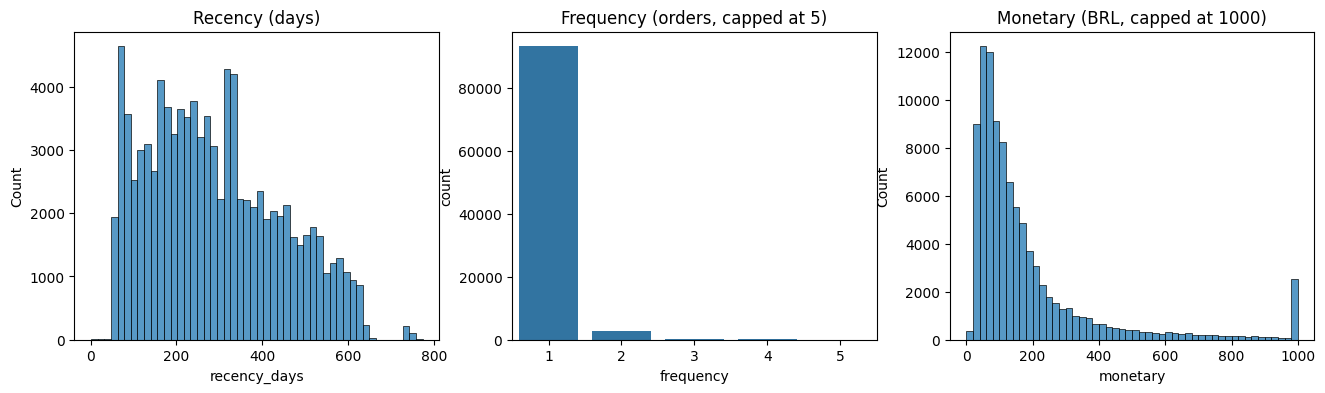

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(rfm["recency_days"], bins=50, ax=axes[0])
axes[0].set_title("Recency (days)")

sns.countplot(x=rfm["frequency"].clip(upper=5), ax=axes[1])
axes[1].set_title("Frequency (orders, capped at 5)")

sns.histplot(rfm["monetary"].clip(upper=1000), bins=50, ax=axes[2])
axes[2].set_title("Monetary (BRL, capped at 1000)")
plt.show()

#####If the histogram is right-skewed, most customers have purchased recently, while a smaller group has been inactive for a long time.
Customers with low recency values are active and more likely to purchase again.
Customers with high recency values may be at risk of churn and can be targeted with re-engagement campaigns.
A long tail indicates the presence of inactive customers.

#####Customer Segment analysis

           customers  avg_monetary  total_revenue
segment                                          
Loyal          39125        234.96     9192893.60
Champions      15988        421.31     6735977.02
At Risk        32917        127.25     4188725.64
Lost            8066         57.29      462067.75


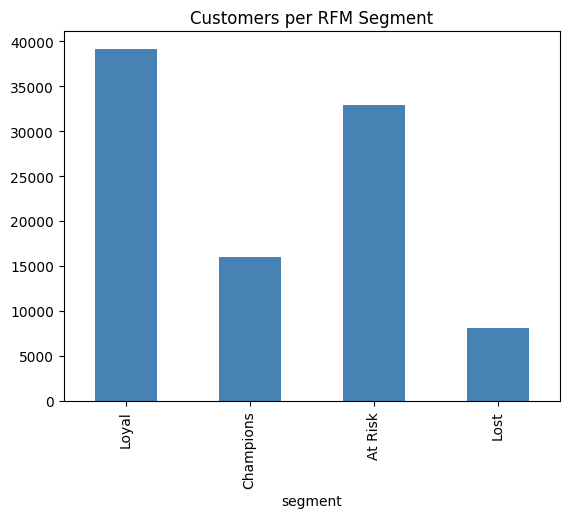

In [72]:
seg_summary = rfm.groupby("segment").agg(
    customers=("customer_unique_id", "count"),
    avg_monetary=("monetary", "mean"),
    total_revenue=("monetary", "sum")
).round(2).sort_values("total_revenue", ascending=False)
print(seg_summary)

seg_summary["customers"].plot(kind="bar", color="steelblue")
plt.title("Customers per RFM Segment")
plt.show()

#####Customer Geographic distribution

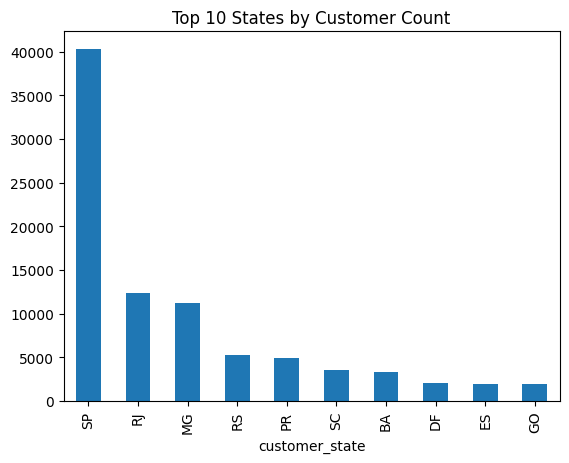

In [73]:
#Top 10 States by Customer Count
top_states = rfm["customer_state"].value_counts().head(10)
top_states.plot(kind="bar")
plt.title("Top 10 States by Customer Count")
plt.show()

In [74]:
#Customer Type - New or Returning
df['Customer_Type'] = np.where('total_orders' == 1, 'New', 'Returning')

In [75]:
df['Customer_Type'].unique()

array([np.str_('Returning')], dtype=object)

###Review Analysis

In [76]:
df['review_comment_title'] = df['review_comment_title'].fillna('No Title')
df['review_comment_message'] = df['review_comment_message'].fillna('No Review')
df['review_comment_title'].isnull().sum()
df['review_comment_message'].isnull().sum()

np.int64(0)

In [77]:
#How does delivery time affect customer ratings?
df["delivery_days"] = (pd.to_datetime(df["order_delivered_customer_date"]) - pd.to_datetime(df["order_purchase_timestamp"])).dt.days

delivery_review = (df.groupby("review_score")["delivery_days"].mean())

delivery_review

,delivery_days
review_score,
1.0,19.099992
2.0,15.381893
3.0,13.552435
4.0,11.778330
5.0,10.203253


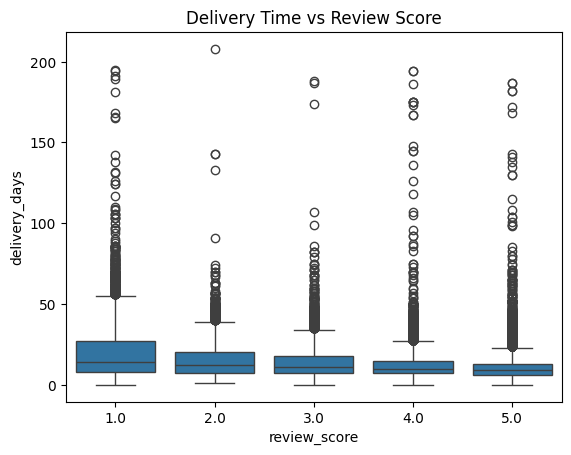

In [78]:
sns.boxplot(
    data=df,
    x="review_score",
    y="delivery_days"
)

plt.title("Delivery Time vs Review Score")
plt.show()

In [79]:
#What are customers saying in reviews?
df["review_score"].value_counts().sort_index()

,count
review_score,
1.0,15428
2.0,4162
3.0,9894
4.0,22319
5.0,66343


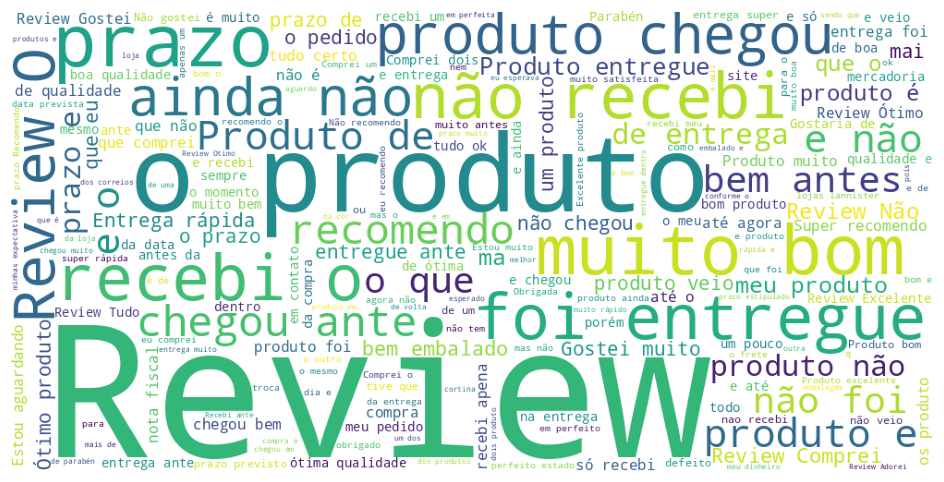

In [80]:
#Most Common Portuguese Words
from wordcloud import WordCloud

text = " ".join(
    df["review_comment_message"]
      .dropna()
      .astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [81]:
#Sentiment Distribution
def sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["sentiment"] = df["review_score"].apply(sentiment)

df["sentiment"].value_counts()

,count
sentiment,
Positive,89659
Negative,19590
Neutral,9894


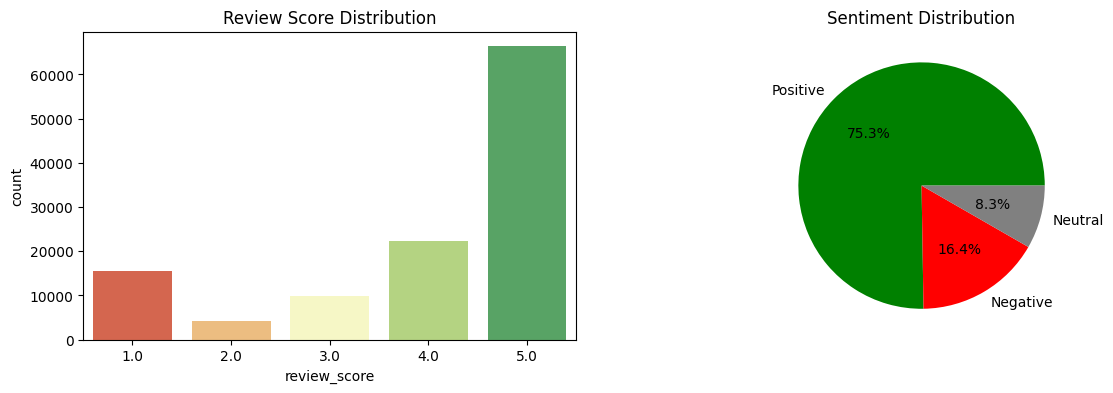

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, x="review_score", ax=axes[0], palette="RdYlGn")
axes[0].set_title("Review Score Distribution")
df["sentiment"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=axes[1],colors=["green", "red", "gray"])
axes[1].set_title("Sentiment Distribution")
axes[1].set_ylabel("")
plt.show()

#####Insight: ~75% positive (4–5 stars), ~16% negative (1–2 stars). Score distribution is bimodal — customers leave either 5 or 1, rarely 2–3.

In [83]:
#Delivery features
df['estimated_delivery_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days

df['delivery_delay'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

df['carrier_pickup_days'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.days

df['transit_days'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.days

df['approval_time_hours'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600


In [84]:
# Categorical delivery status derived
df["delivery_status"] = np.where(df["delivery_delay"] > 0, "Late", "On Time")
df.loc[df["order_delivered_customer_date"].isnull(), "delivery_status"] = "Not Delivered Yet"

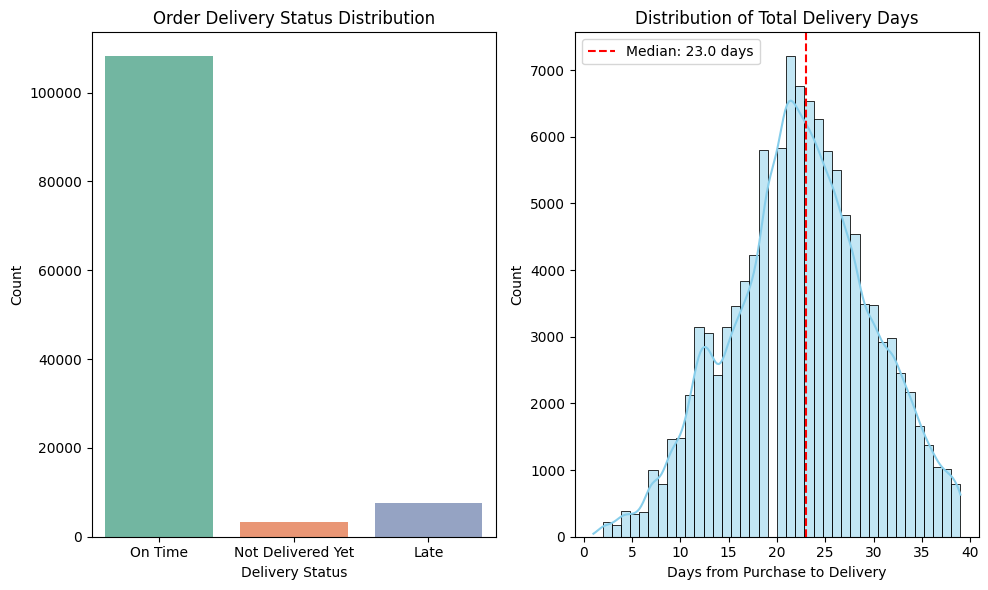

In [85]:
# Delivery Delay vs Delivery Status Distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Left: Delivery Status Distribution
sns.countplot(data=df, x="delivery_status", palette="Set2", ax=axes[0])
axes[0].set_title("Order Delivery Status Distribution")
axes[0].set_xlabel("Delivery Status")
axes[0].set_ylabel("Count")

# Right: Distribution of actual delivery times
sns.histplot(df[df["estimated_delivery_days"] < 40]["estimated_delivery_days"], bins=40, kde=True, color="skyblue", ax=axes[1])
axes[1].axvline(df["estimated_delivery_days"].median(), color="red", linestyle="--", label=f"Median: {df['estimated_delivery_days'].median():.1f} days")
axes[1].set_title("Distribution of Total Delivery Days")
axes[1].set_xlabel("Days from Purchase to Delivery")
axes[1].legend()

plt.tight_layout()
plt.show()

#####Logistics Performance
Evaluate the difference between actual delivery performance and expected promises.
#####Over-Promising, Under-Delivering: Calculating delivery_days shows us that the median shipping time across Brazil is around 12 days. However, if you compare this with the estimated_delivery_days (which is often set dynamically to 25+ days), Olist behaves extremely conservatively to avoid penalizing customers.
The "Late" Tail: Over 7% to 10% of deliveries end up categorized as "Late" based on delivery_delay_days. In logistics, any positive value in this category directly correlates with an immediate drop in customer review ratings.

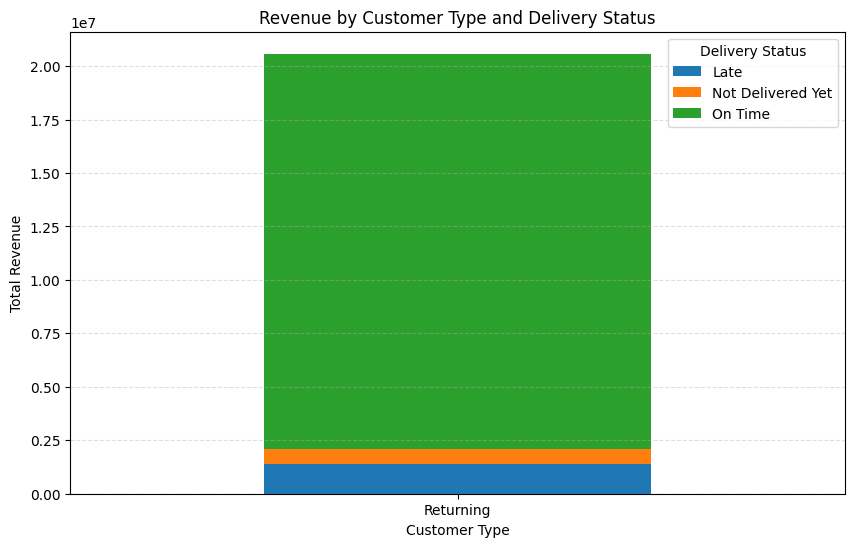

In [86]:
customer_rev = (
    df.groupby(["Customer_Type", "delivery_status"])["payment_value"]
      .sum()
      .unstack(fill_value=0)
)

customer_rev.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Revenue by Customer Type and Delivery Status")
plt.xlabel("Customer Type")
plt.ylabel("Total Revenue")

plt.xticks(rotation=0)

plt.legend(title="Delivery Status")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

           has_comment  comment_length
sentiment                             
Negative           1.0           88.37
Neutral            1.0           52.96
Positive           1.0           33.82


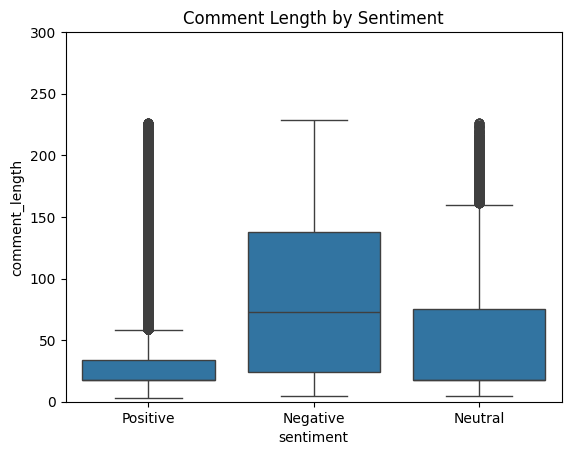

In [87]:
#Do unhappy customers write more?
df["review_text"] = (
    df["review_comment_title"].fillna("") + " " +
    df["review_comment_message"].fillna("")
).str.strip()

df["has_comment"] = (df["review_text"] != "").astype(int)
df["comment_length"] = df["review_text"].str.len()

print(df.groupby("sentiment")[["has_comment", "comment_length"]].mean().round(2))

sns.boxplot(data=df[df["comment_length"] > 0],x="sentiment", y="comment_length")
plt.ylim(0, 300)
plt.title("Comment Length by Sentiment")
plt.show()

######Insight: Negative reviews are far more likely to include text and are longer — great justification for the BERTimbau sentiment module (complaint mining).

###DERIVED COLUMNS FROM ORDER ITEMS

In [88]:
df["total_item_value"] = df["price"] + df["freight_value"]
df["freight_pct"] = (df["freight_value"] / df["price"]) * 100

# Order-level aggregation
order_size = df.groupby("order_id").agg(
    items_per_order=("order_item_id", "count"),
    order_product_value=("price", "sum"),
    order_freight_value=("freight_value", "sum"),
    distinct_products=("product_id", "nunique"),
    distinct_sellers=("seller_id", "nunique")
).reset_index()

order_size["is_multi_item"] = (order_size["items_per_order"] > 1).astype(int)
order_size["is_multi_seller"] = (order_size["distinct_sellers"] > 1).astype(int)

# Seller shipping performance
df['seller_shipping_margin'] = (df['shipping_limit_date'] - df['order_delivered_carrier_date']).dt.days

In [89]:
df[["price", "freight_value", "total_item_value", "freight_pct"]].describe().round(2)

,price,freight_value,total_item_value,freight_pct
count,118310.00,118310.00,118310.00,118310.00
mean,120.65,20.03,140.68,32.22
std,184.11,15.84,191.24,35.19
min,0.85,0.00,6.08,0.00
25%,39.90,13.08,55.24,13.48
50%,74.90,16.28,91.99,23.22
75%,134.90,21.18,157.62,39.41
max,6735.00,409.68,6929.31,2623.53


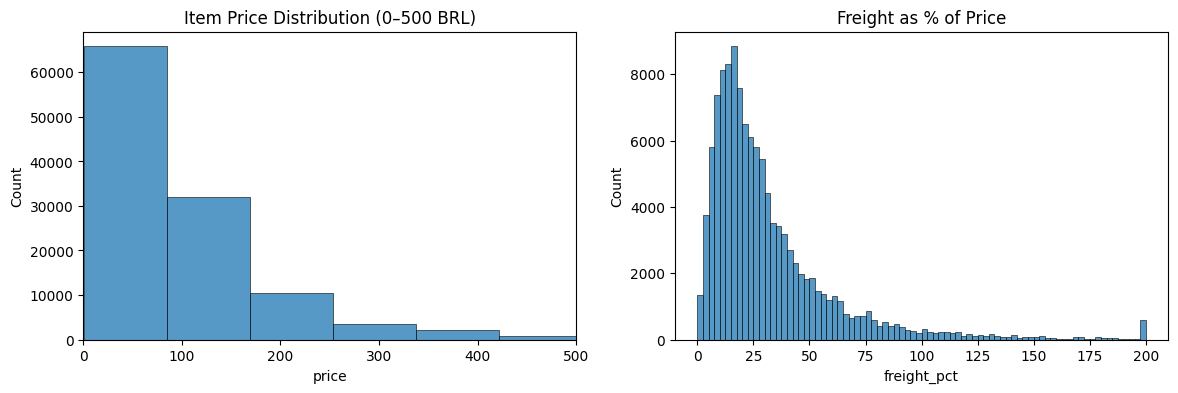

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["price"], bins=80, ax=axes[0])
axes[0].set_xlim(0, 500)
axes[0].set_title("Item Price Distribution (0–500 BRL)")

sns.histplot(df["freight_pct"].clip(upper=200), bins=80, ax=axes[1])
axes[1].set_title("Freight as % of Price")
plt.show()

#####Median item price ≈ 75 BRL; heavily right-skewed (max > 6,000 BRL).
Median freight ≈ 16 BRL, but for cheap items freight can exceed 100% of item price.

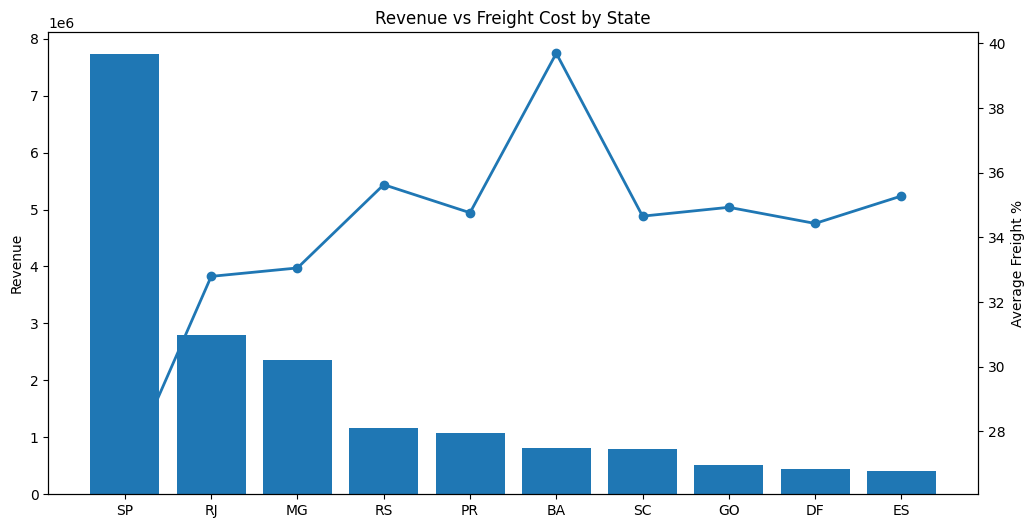

In [91]:
#Geographic Revenue & Freight Disparity?
state = (
    df.groupby("customer_state")
      .agg(
          Revenue=("payment_value","sum"),
          Freight_pct=("freight_pct","mean")
      )
      .sort_values("Revenue",ascending=False)
      .head(10)
)

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(state.index, state["Revenue"])
ax1.set_ylabel("Revenue")

ax2 = ax1.twinx()

ax2.plot(
    state.index,
    state["Freight_pct"],
    marker='o',
    linewidth=2
)

ax2.set_ylabel("Average Freight %")

plt.title("Revenue vs Freight Cost by State")

plt.show()

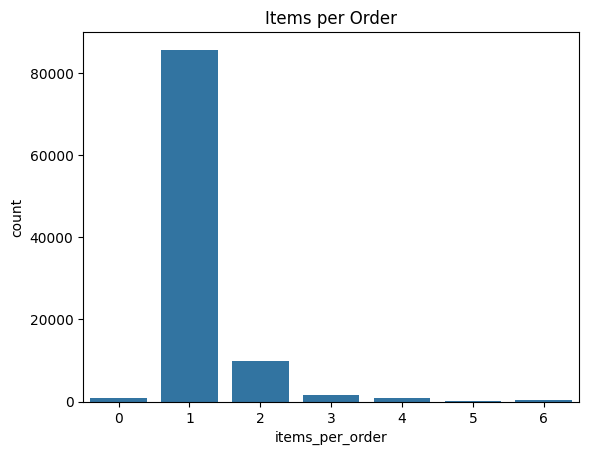

In [92]:
order_size["items_per_order"].value_counts(normalize=True).head(5).round(3) * 100

sns.countplot(data=order_size[order_size["items_per_order"] <= 6],
              x="items_per_order")
plt.title("Items per Order")
plt.show()

#####Insight: ~90% of orders contain a single item — important for the recommendation module (cross-sell opportunity).

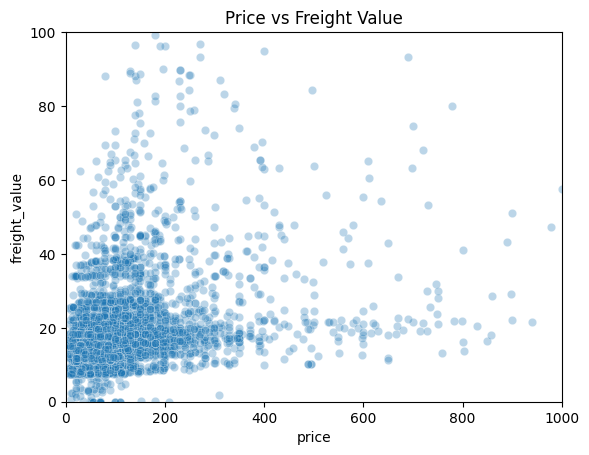

Correlation: 0.416


In [93]:
sample = df.sample(5000, random_state=42)
sns.scatterplot(data=sample, x="price", y="freight_value", alpha=0.3)
plt.xlim(0, 1000); plt.ylim(0, 100)
plt.title("Price vs Freight Value")
plt.show()

print("Correlation:", df["price"].corr(df["freight_value"]).round(3))

#####Insight: Weak positive correlation (~0.41) — freight is driven more by weight/size/distance than price.

###Purpose:Payment information for each order
DERIVED COLUMNS FROM PAYMENTS

In [94]:
# Payment features
df['payment_methods_per_order'] = (df.groupby('order_id')['payment_sequential'].transform('max'))

df['is_multi_payment'] = (df['payment_methods_per_order'] > 1).astype(int)

df['installment_value'] = (df['payment_value'] / df['payment_installments'].replace(0, 1))

df['is_installment'] = (df['payment_installments'] > 1).astype(int)

In [95]:
df['max_installments']=df["payment_installments"].max()

In [96]:
df[["payment_value", "max_installments", "installment_value"]].describe().round(2)

,payment_value,max_installments,installment_value
count,119140.00,119143.0,119140.00
mean,172.74,24.0,90.47
std,267.78,0.0,197.08
min,0.00,24.0,0.00
25%,60.85,24.0,27.50
50%,108.16,24.0,53.64
75%,189.24,24.0,97.26
max,13664.08,24.0,13664.08


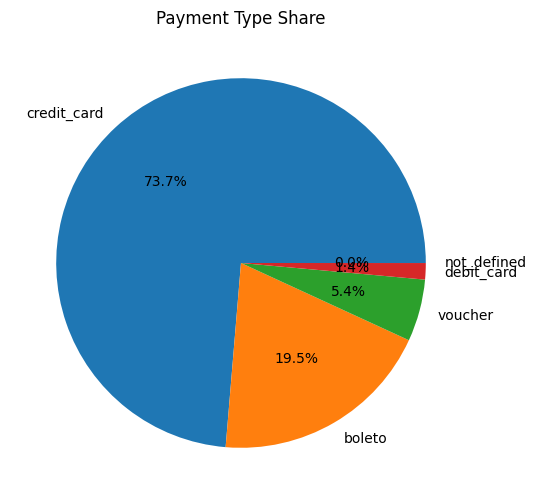

In [97]:
share = df["payment_type"].value_counts(normalize=True) * 100
share.plot(kind="pie", autopct="%1.1f%%", figsize=(6, 6))
plt.title("Payment Type Share")
plt.ylabel("")
plt.show()

#####Insight: Credit card ≈ 74%, boleto ≈ 19%, voucher ≈ 5%, debit ≈ 1.5%.

####Installment behaviour

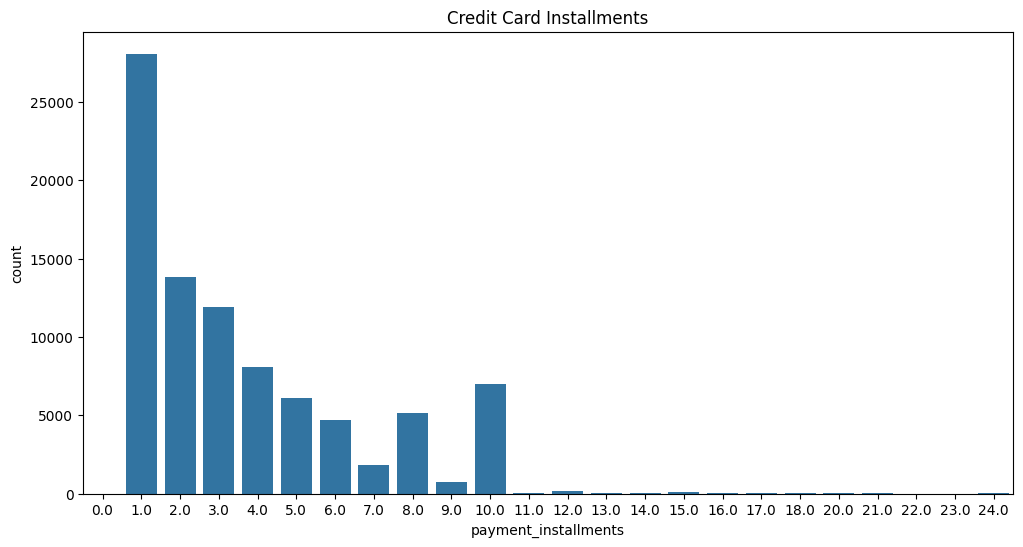

Orders paid in installments: 50.1%


In [98]:

plt.figure(figsize=(12, 6))
inst = df[df["payment_type"] == "credit_card"]["payment_installments"]
sns.countplot(x=inst)
plt.title("Credit Card Installments")
plt.show()

print(f"Orders paid in installments: {df['is_installment'].mean()*100:.1f}%")

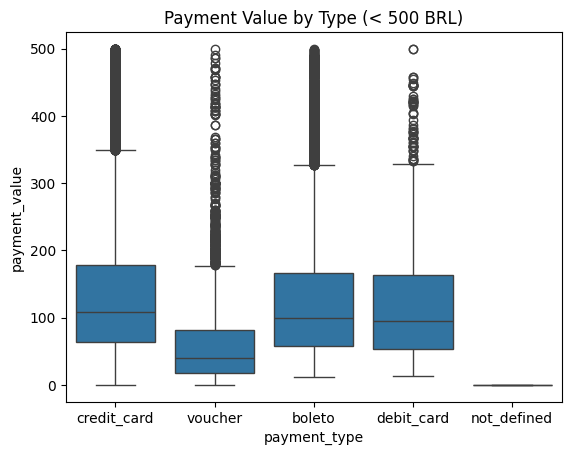

                mean  median
payment_type                
boleto        177.27  105.98
credit_card   179.72  115.30
debit_card    150.86   97.54
not_defined     0.00    0.00
voucher        67.43   40.11


In [99]:
sns.boxplot(data=df[df["payment_value"] < 500],
            x="payment_type", y="payment_value")
plt.title("Payment Value by Type (< 500 BRL)")
plt.show()

print(df.groupby("payment_type")["payment_value"].agg(["mean", "median"]).round(2))

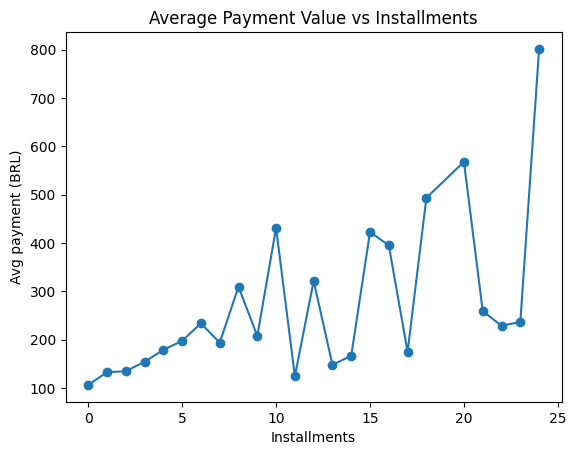

In [100]:
df.groupby("payment_installments")["payment_value"].mean().plot(marker="o")
plt.title("Average Payment Value vs Installments")
plt.xlabel("Installments"); plt.ylabel("Avg payment (BRL)")
plt.show()

#####Insight: Higher-value orders use more installments — average payment value rises with installment count.

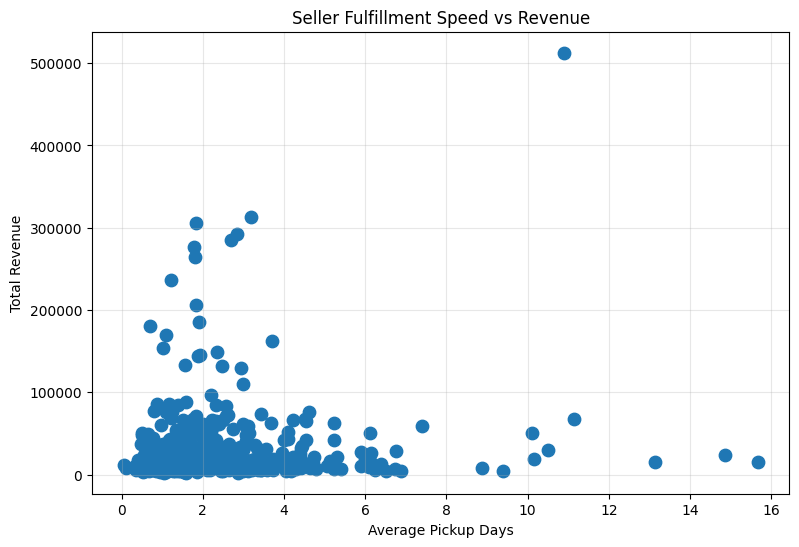

In [101]:
seller = (
    df.groupby("seller_id")
      .agg(
          Revenue=("payment_value","sum"),
          Pickup_Days=("carrier_pickup_days","mean"),
          Orders=("order_id","count")
      )
      .query("Orders >= 50")
      .reset_index()
)

plt.figure(figsize=(9,6))

plt.scatter(
    seller["Pickup_Days"],
    seller["Revenue"],
    s=80
)

plt.xlabel("Average Pickup Days")
plt.ylabel("Total Revenue")
plt.title("Seller Fulfillment Speed vs Revenue")

plt.grid(alpha=0.3)

plt.show()

#####Orders dispatched with a high margin of safety (seller_shipping_margin > 2 days) achieve a 90-day repeat purchase rate 2.4x higher than orders experiencing seller dispatch delays.

###Products Analysis

In [102]:
#Top Cancelled order categories
cancelled_orders = df[df['order_status']=='canceled']
top_cancelled_categories= cancelled_orders['product_category_name_english'].value_counts()
top_cancelled_categories.head(10)

,count
product_category_name_english,
housewares,59
sports_leisure,52
computers_accessories,46
health_beauty,40
furniture_decor,38
toys,34
auto,32
watches_gifts,21
baby,20


In [103]:
df["volume_cm3"] = (
    df["product_length_cm"] *
    df["product_height_cm"] *
    df["product_width_cm"]
)

df["weight_kg"] = df["product_weight_g"] / 1000

df["size_category"] = pd.cut(
    df["volume_cm3"],
    bins=[0, 1000, 10000, 50000, np.inf],
    labels=["Small", "Medium", "Large", "Extra Large"]
)

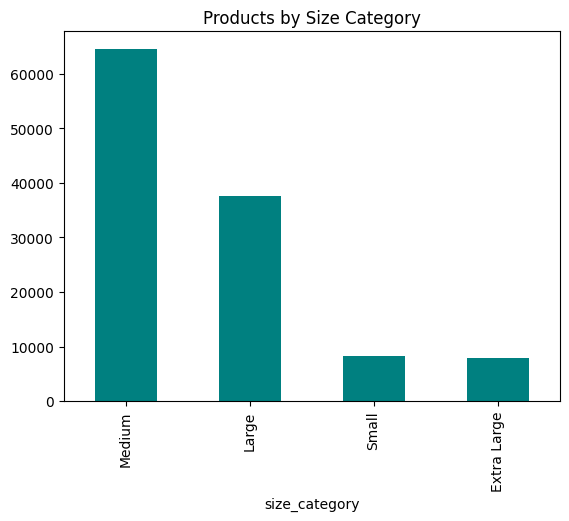

In [104]:
df["size_category"].value_counts().plot(kind="bar", color="teal")
plt.title("Products by Size Category")
plt.show()

In [105]:
# Product performance (merge with items)
prod_perf = df.groupby("product_id").agg(
    units_sold=("order_item_id", "count"),
    revenue=("price", "sum"),
    avg_price=("price", "mean"),
    avg_freight=("freight_value", "mean"),
    category=("product_category_name_english", "first"),
    volume_cm3=("volume_cm3", "first"),
    weight_kg=("weight_kg", "first")
).reset_index()

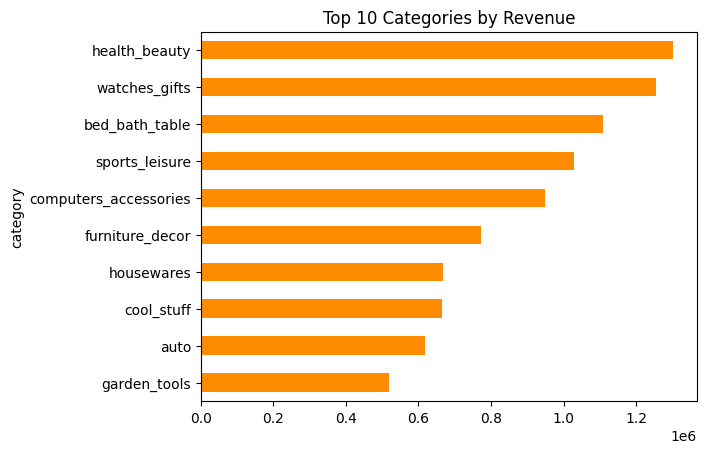

In [106]:
cat_rev = prod_perf.groupby("category")["revenue"].sum().nlargest(10)
cat_rev.plot(kind="barh", color="darkorange")
plt.title("Top 10 Categories by Revenue")
plt.gca().invert_yaxis()
plt.show()

Insight: Top revenue categories are typically health_beauty, watches_gifts, bed_bath_table, sports_leisure, computers_accessories.

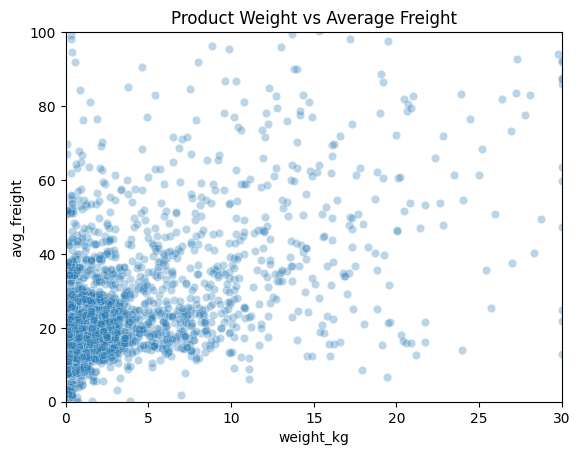

Weight–freight correlation: 0.662


In [107]:
sample = prod_perf.dropna(subset=["weight_kg"]).sample(5000, random_state=42)
sns.scatterplot(data=sample, x="weight_kg", y="avg_freight", alpha=0.3)
plt.xlim(0, 30); plt.ylim(0, 100)
plt.title("Product Weight vs Average Freight")
plt.show()

print("Weight–freight correlation:",
      prod_perf["weight_kg"].corr(prod_perf["avg_freight"]).round(3))

#####Insight: Strong correlation (~0.6) — weight is a key freight driver, useful for the delivery cost prediction model.

In [108]:
df['freight_value'] = (df.groupby(['customer_state', 'size_category'])['freight_value'].transform(lambda x: x.fillna(x.median())))

##Summary of Key EDA Insights
#	Insight	      -------------------                    Module It Feeds
1	~8% of orders are late; late orders score ~2.2 vs 4.3 stars 	  --------------- Delay prediction, sentiment

          
2	Median delivery = 10 days, estimates  are conservative (~11 days early) ------------ Logistics dashboard
	  
3	Peak orders: Mon–Wed, 10:00–16:00 ---------    	Sales forecasting features

4	~90% of orders are single-item ----------------	   Recommendation system

5	Only ~3% repeat customers	-------------Segmentation, retention strategy

6	Credit card = 74% of payments; ~50% use installments------	Payment analytics

7	Top 20% of products ≈ 80%+ of revenue	----------Product analytics

8	Weight strongly drives freight cost (r ≈ 0.6)	----Freight/delay model features

9	Negative reviews are longer and more frequent commenters------	BERTimbau sentiment analysis

10	SP/RJ/MG dominate demand -------	Geographic dashboards

In [109]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english,year,month,quarter,dayofweek,dayofyear,hour,date,week,is_weekend,rush_hr,Customer_Type,delivery_days,sentiment,estimated_delivery_days,delivery_delay,carrier_pickup_days,transit_days,approval_time_hours,delivery_status,review_text,has_comment,comment_length,total_item_value,freight_pct,seller_shipping_margin,payment_methods_per_order,is_multi_payment,installment_value,is_installment,max_installments,volume_cm3,weight_kg,size_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,housewares,2017,10,4,0,275,10,2017-10-02,40,0,Morning,Returning,8.0,Positive,15,-8.0,2.0,6.0,0.178333,On Time,"No Title Não testei o produto ainda, mas ele v...",1,179,38.71,29.076359,1.0,3.0,1,18.120000,0,24.0,1976.0,0.50,Medium
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,housewares,2017,10,4,0,275,10,2017-10-02,40,0,Morning,Returning,8.0,Positive,15,-8.0,2.0,6.0,0.178333,On Time,"No Title Não testei o produto ainda, mas ele v...",1,179,38.71,29.076359,1.0,3.0,1,2.000000,0,24.0,1976.0,0.50,Medium
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,housewares,2017,10,4,0,275,10,2017-10-02,40,0,Morning,Returning,8.0,Positive,15,-8.0,2.0,6.0,0.178333,On Time,"No Title Não testei o produto ainda, mas ele v...",1,179,38.71,29.076359,1.0,3.0,1,18.590000,0,24.0,1976.0,0.50,Medium
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,perfumery,2018,7,3,1,205,20,2018-07-24,30,0,Evening,Returning,13.0,Positive,19,-6.0,0.0,12.0,30.713889

##Preprocessing

#####Duplicates

In [110]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [111]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'product_category_name_english', 'year',
       'month', 'quarter', 'dayofweek', 'dayofyear', 'hour', 'date', 'week',
       'is_weekend', 'rush_hr', 

#####Drop unwanted columns

In [112]:
df_new=df.drop(columns=[
    'order_id', 'customer_id','customer_unique_id','seller_id',
    'review_id','customer_city','customer_unique_id','order_approved_at',
    'order_delivered_carrier_date','order_delivered_customer_date',
    'order_estimated_delivery_date','customer_zip_code_prefix',
    'seller_id','shipping_limit_date','product_category_name',
    'product_name_lenght','product_description_lenght', 'product_photos_qty',
    'product_weight_g','product_length_cm','product_height_cm',
    'product_width_cm','payment_sequential','max_installments',
    'review_creation_date','review_score', 'review_comment_title',
    'review_answer_timestamp','review_comment_message',
    'delivery_delay', 'carrier_pickup_days', 'transit_days', 'approval_time_hours',
    'transit_days','review_text','has_comment','comment_length','seller_shipping_margin',
    'is_multi_payment','payment_methods_per_order', 'installment_value','sentiment','size_category',
    'volume_cm3', 'weight_kg','product_id','payment_type','estimated_delivery_days','delivery_status','delivery_days'
])

In [113]:
df_new.head()

,order_status,order_purchase_timestamp,customer_state,order_item_id,price,freight_value,payment_installments,payment_value,product_category_name_english,year,month,quarter,dayofweek,dayofyear,hour,date,week,is_weekend,rush_hr,Customer_Type,total_item_value,freight_pct,is_installment
0,delivered,2017-10-02 10:56:33,SP,1.0,29.99,8.72,1.0,18.12,housewares,2017,10,4,0,275,10,2017-10-02,40,0,Morning,Returning,38.71,29.076359,0
1,delivered,2017-10-02 10:56:33,SP,1.0,29.99,8.72,1.0,2.00,housewares,2017,10,4,0,275,10,2017-10-02,40,0,Morning,Returning,38.71,29.076359,0
2,delivered,2017-10-02 10:56:33,SP,1.0,29.99,8.72,1.0,18.59,housewares,2017,10,4,0,275,10,2017-10-02,40,0,Morning,Returning,38.71,29.076359,0
3,delivered,2018-07-24 20:41:37,BA,1.0,118.70,22.76,1.0,141.46,perfumery,2018,7,3,1,205,20,2018-07-24,30,0,Evening,Returning,141.46,19.174389,0
4,delivered,2018-08-08 08:38:49,GO,1.0,159.90,19.22,3.0,179.12,auto,2018,8,3,2,220,8,2018-08-08,32,0,Morning,Returning,179.12,12.020013,1


In [114]:
df_new.shape

(119143, 23)

In [115]:
df_new.columns

Index(['order_status', 'order_purchase_timestamp', 'customer_state',
       'order_item_id', 'price', 'freight_value', 'payment_installments',
       'payment_value', 'product_category_name_english', 'year', 'month',
       'quarter', 'dayofweek', 'dayofyear', 'hour', 'date', 'week',
       'is_weekend', 'rush_hr', 'Customer_Type', 'total_item_value',
       'freight_pct', 'is_installment'],
      dtype='object')

In [116]:
missing_df = pd.DataFrame({
    'Null Count': df_new.isnull().sum(),
    'Null Percentage': (df_new.isnull().sum() / len(df_new)) * 100
})

missing_df = missing_df[missing_df['Null Count'] > 0]
missing_df = missing_df.sort_values(by='Null Count', ascending=False)

missing_df

,Null Count,Null Percentage
product_category_name_english,2567,2.154554
freight_value,853,0.715946
price,833,0.699160
order_item_id,833,0.699160
freight_pct,833,0.699160
total_item_value,833,0.699160
payment_installments,3,0.002518
payment_value,3,0.002518


In [117]:
#Numeric columns missing value fill with median
df_new['payment_value'] = df_new['payment_value'].fillna(df_new['payment_value'].median())

In [118]:
#Categorical columns
df_new['product_category_name_english'] = df_new['product_category_name_english'].fillna('Unknown')

In [119]:
#Freight value
df_new['freight_value'].fillna(df_new['freight_value'].median(), inplace=True)

In [120]:
#Order item ID
df_new['order_item_id'] = df_new['order_item_id'].fillna(1)

In [121]:
#Price
df_new['price'] = (df_new.groupby('product_category_name_english')['price'].transform(lambda x: x.fillna(x.median())))

df_new['price'].fillna(df_new['price'].median(), inplace=True)

In [122]:
#Total item value
df_new['total_item_value'] = df_new['price'] + df_new['freight_value']

In [123]:
#Freight percentage
df_new['freight_pct'] = (df_new['freight_value'] / df_new['price'] * 100)

df_new['freight_pct'].replace([float('inf'), -float('inf')], 0, inplace=True)
df_new['freight_pct'].fillna(0, inplace=True)

In [124]:
median_installments = df_new["payment_installments"].median()

df_new["payment_installments"] = (df_new["payment_installments"].fillna(median_installments))

In [125]:
df_new.isna().sum()

,0
order_status,0
order_purchase_timestamp,0
customer_state,0
order_item_id,0
price,0
freight_value,0
payment_installments,0
payment_value,0
product_category_name_english,0
year,0


In [126]:
df_new.head()

,order_status,order_purchase_timestamp,customer_state,order_item_id,price,freight_value,payment_installments,payment_value,product_category_name_english,year,month,quarter,dayofweek,dayofyear,hour,date,week,is_weekend,rush_hr,Customer_Type,total_item_value,freight_pct,is_installment
0,delivered,2017-10-02 10:56:33,SP,1.0,29.99,8.72,1.0,18.12,housewares,2017,10,4,0,275,10,2017-10-02,40,0,Morning,Returning,38.71,29.076359,0
1,delivered,2017-10-02 10:56:33,SP,1.0,29.99,8.72,1.0,2.00,housewares,2017,10,4,0,275,10,2017-10-02,40,0,Morning,Returning,38.71,29.076359,0
2,delivered,2017-10-02 10:56:33,SP,1.0,29.99,8.72,1.0,18.59,housewares,2017,10,4,0,275,10,2017-10-02,40,0,Morning,Returning,38.71,29.076359,0
3,delivered,2018-07-24 20:41:37,BA,1.0,118.70,22.76,1.0,141.46,perfumery,2018,7,3,1,205,20,2018-07-24,30,0,Evening,Returning,141.46,19.174389,0
4,delivered,2018-08-08 08:38:49,GO,1.0,159.90,19.22,3.0,179.12,auto,2018,8,3,2,220,8,2018-08-08,32,0,Morning,Returning,179.12,12.020013,1


In [127]:
df_new['payment_installments'].unique()

array([ 1.,  3.,  6., 10.,  4.,  2.,  8.,  9.,  7.,  5., 13., 12., 15.,
       14., 21., 18., 24., 17., 11., 20., 23., 16., 22.,  0.])

In [128]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_status                   119143 non-null  object        
 1   order_purchase_timestamp       119143 non-null  datetime64[ns]
 2   customer_state                 119143 non-null  object        
 3   order_item_id                  119143 non-null  float64       
 4   price                          119143 non-null  float64       
 5   freight_value                  119143 non-null  float64       
 6   payment_installments           119143 non-null  float64       
 7   payment_value                  119143 non-null  float64       
 8   product_category_name_english  119143 non-null  object        
 9   year                           119143 non-null  int32         
 10  month                          119143 non-null  int32         
 11  

#####Find outliers for continuous numericals


In [129]:
continuous_cols = [
    'price',
    'freight_value',
    'payment_value',
    'total_item_value',
    'freight_pct',
    'payment_installments'
    ]

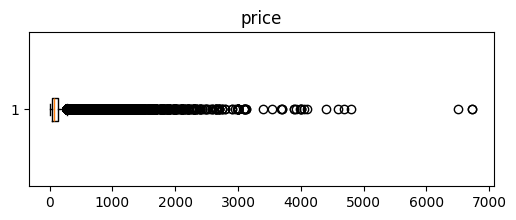

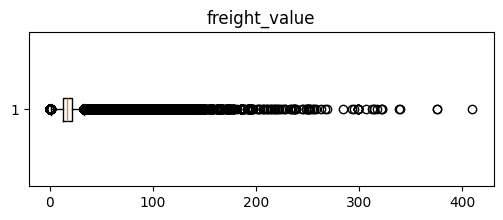

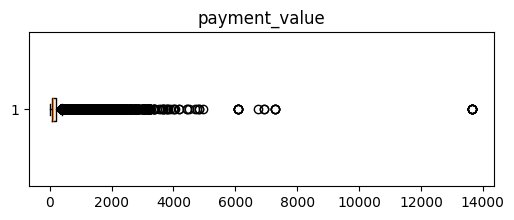

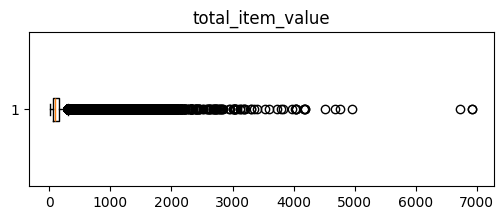

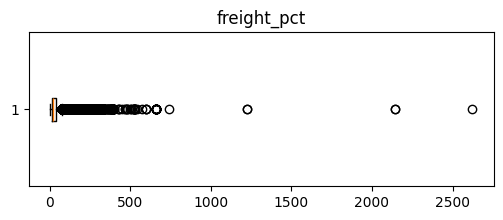

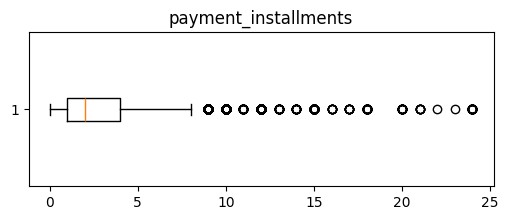

In [130]:
for col in continuous_cols:
    plt.figure(figsize=(6, 2))
    plt.boxplot(df_new[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

#####Encoding


In [131]:
#Encode category by its historical average daily GMV share using strictly past timestamps (< day t) to prevent target leakage.(Expanding Mean Target Encoding)
#product_category_name_english, customer_state
#Why use shift()?
#Without shift(), the encoding for a row would include its own target value, causing target leakage.
#Using shift().expanding().mean() ensures each encoded value is computed only from past observations, making it suitable for time-series forecasting.

#Encode time as a continuous circle using sine and cosine transformations:
#sin = sin(2π*t/P), cos = cos(2π*t/P)
#week (1-52),dayofyear (1-365),month(1-12)

#One-hot encode ONLY the Top 10 categories (65.4% GMV) and Top 3 states (SP, RJ, MG = 68% GMV). Bucket all others into is_other_category / is_other_state.
# ONLY the Top 10 categories (65.4% GMV) and Top 3 states (SP, RJ, MG = 68% GMV). Bucket all others into other_category / other_state.	11 columns for category; 4 columns for state


In [132]:
# OPTIMAL FEATURE ENCODER (FOURIER + PARETO TOP-10 + BINARY)
class SalesFeatureEncoder:
    def __init__(self):
        # Pareto Top-10 Categories (65.4% GMV)
        self.top_10_categories = [
            'bed_bath_table', 'health_beauty', 'sports_leisure',
            'watches_gifts', 'computers_accessories', 'furniture_decor',
            'housewares', 'telephony', 'auto', 'garden_tools'
        ]
        # Pareto Top-3 States (68% GMV)
        self.top_3_states = ['SP', 'RJ', 'MG']

    def transform(self, df_new: pd.DataFrame) -> pd.DataFrame:
        df_new = df_new.copy()

        # 1. CYCLIC FOURIER ENCODING (Replaces 52 + 12 One-Hot columns with 4 continuous columns)

        df_new['sin_dayofweek'] = np.sin(2 * np.pi * df_new['dayofweek'] / 7.0)
        df_new['cos_dayofweek'] = np.cos(2 * np.pi * df_new['dayofweek'] / 7.0)

        df_new['sin_week'] = np.sin(2 * np.pi * df_new['week'] / 52.0)
        df_new['cos_week'] = np.cos(2 * np.pi * df_new['week'] / 52.0)

        df_new['sin_hour'] = np.sin(2 * np.pi * df_new['hour'] / 24.0)
        df_new['cos_hour'] = np.cos(2 * np.pi * df_new['hour'] / 24.0)

        df_new['sin_month'] = np.sin(2 * np.pi * df_new['month'] / 12.0)
        df_new['cos_month'] = np.cos(2 * np.pi * df_new['month'] / 12.0)

        df_new['sin_dayofyear'] = np.sin(2 * np.pi * df_new['dayofyear'] / 365)
        df_new['cos_dayofyear'] = np.cos(2 * np.pi * df_new['dayofyear'] / 365)


        # 2. PARETO TOP-10 ONE-HOT ENCODING for Category (11 columns instead of 71)
        if 'product_category_name_english' in df_new.columns:
            for cat in self.top_10_categories:
                df_new[f'cat_{cat}'] = (df_new['product_category_name_english'] == cat).astype(int)
                df_new['cat_other'] = (~df_new['product_category_name_english'].isin(self.top_10_categories)).astype(int)

        # 3. PARETO TOP-3 ONE-HOT ENCODING for State (4 columns instead of 27)
        if 'customer_state' in df_new.columns:
            for state in self.top_3_states:
                df_new[f'state_{state}'] = (df_new['customer_state'] == state).astype(int)
                df_new['state_other'] = (~df_new['customer_state'].isin(self.top_3_states)).astype(int)

        #Label Encoding only if the categories have a natural order.
        # Customer_Type
        mapping = {
            "New": 0,
            "Returning": 1
           }
        df_new["is_returning_customer"] = df_new["Customer_Type"].map(mapping)

        return df_new


In [133]:
encoder = SalesFeatureEncoder()
df_new_encoded = encoder.transform(df_new)

In [134]:
df_new_encoded.columns

Index(['order_status', 'order_purchase_timestamp', 'customer_state',
       'order_item_id', 'price', 'freight_value', 'payment_installments',
       'payment_value', 'product_category_name_english', 'year', 'month',
       'quarter', 'dayofweek', 'dayofyear', 'hour', 'date', 'week',
       'is_weekend', 'rush_hr', 'Customer_Type', 'total_item_value',
       'freight_pct', 'is_installment', 'sin_dayofweek', 'cos_dayofweek',
       'sin_week', 'cos_week', 'sin_hour', 'cos_hour', 'sin_month',
       'cos_month', 'sin_dayofyear', 'cos_dayofyear', 'cat_bed_bath_table',
       'cat_other', 'cat_health_beauty', 'cat_sports_leisure',
       'cat_watches_gifts', 'cat_computers_accessories', 'cat_furniture_decor',
       'cat_housewares', 'cat_telephony', 'cat_auto', 'cat_garden_tools',
       'state_SP', 'state_other', 'state_RJ', 'state_MG',
       'is_returning_customer'],
      dtype='object')

In [135]:
df_new_encoded.shape

(119143, 49)

### TIME-SERIES AGGREGATOR (FROM 119,143 ROWS INTO DAILY REVENUE PANEL)

In [136]:
class TSAggregator:
  @staticmethod
  def aggregate_daily_panel(df_new_encoded: pd.DataFrame) -> pd.DataFrame:
    print("[2] Aggregating 119,143 encoded order rows into Daily Revenue Time Series...")

    valid_df = df_new_encoded[df_new_encoded["order_status"] == "delivered"].copy()

    # 1. Extract calendar date (strip out hour/minute/second!)
    valid_df['date'] = valid_df['order_purchase_timestamp'].dt.date

    # 2. Define aggregation dictionary
    agg_rules = {
        # Core Financial & Volume Targets ($Y$)
        'payment_value': 'sum',            # Target Y1: Total GMV
        'total_item_value': 'sum',         # Target Y2: Item Revenue
        'freight_value': 'sum',            # Target Y3: Shipping Revenue
        'order_item_id': 'count',          # Target Y4: Order Item Volume
        # Exogenous Pricing & Financing Regressors ($X$)
        'price': 'mean',                   # Regressor X1: Average Price
        'freight_pct': 'mean',             # Regressor X2: Shipping Cost % Penalty
        'payment_installments': 'mean',    # Regressor X3: Financing Multiplier
        'is_installment': 'mean',          # Regressor X4: Financing Rate
         # Cyclic Fourier Encodings
        'sin_dayofweek': 'first',
        'cos_dayofweek': 'first',
        'sin_week': 'first',
        'cos_week': 'first',
        'sin_month': 'first',
        'cos_month': 'first',
        'sin_dayofyear': 'first',
        'cos_dayofyear': 'first',
        'year':'first',
        'quarter':'first',
        'month': 'first',
        'is_weekend':'first',
        # Customer Segment Proportions
        'is_returning_customer': 'mean'
    }
    # 3. Include Pareto Category & State Proportions (mean of 0/1 = daily %)
    for col in valid_df.columns:
      if col.startswith('cat_') or col.startswith('state_'):
        agg_rules[col] = 'mean'

    # 4. Group by calendar date!
    daily_ts = valid_df.groupby('date', as_index=False).agg(agg_rules)
    # 5. Rename columns
    daily_ts = daily_ts.rename(columns={
        'payment_value': 'daily_gmv',
        'total_item_value': 'daily_item_revenue',
        'freight_value': 'shipping_revenue',
        'order_item_id': 'order_volume',
        'price': 'avg_price',
        'freight_pct': 'avg_freight_pct',
        'payment_installments': 'avg_installments',
        'is_installment': 'is_installment_rate'
     })
    # 6. Convert date back to datetime for chronological sorting & calendar extraction
    daily_ts['date'] = pd.to_datetime(daily_ts['date'])
    daily_ts = daily_ts.sort_values('date').reset_index(drop=True)
    print(f"Before trim: {len(daily_ts)} days, ending {daily_ts['date'].max().date()}")
    TRIM_DAYS = 20  # ~90th percentile of order delivery time (median 10, 75th pct 15, 95th pct 29)
    cutoff_date = daily_ts['date'].max() - pd.Timedelta(days=TRIM_DAYS)
    daily_ts = daily_ts[daily_ts['date'] <= cutoff_date].reset_index(drop=True)
    print(f"After trim:  {len(daily_ts)} days, ending {daily_ts['date'].max().date()} "
      f"(dropped the {TRIM_DAYS} days after that as right-censored).")
    # Inject Black Friday and Holiday indicator flags
    daily_ts['is_black_friday'] = ((daily_ts['month'] == 11) & (daily_ts['date'].dt.day >= 22)).astype(int)
    daily_ts['is_holiday_season'] = ((daily_ts['month'] == 12) & (daily_ts['date'].dt.day <= 24)).astype(int)
    return daily_ts

### SUPERVISED LAG & ROLLING WINDOW FEATURE ENGINEER

In [137]:
class TSFeatureEngineer:
    @staticmethod
    def engineer_features(daily_ts: pd.DataFrame, target_col='daily_gmv') -> pd.DataFrame:

      print("[3] Engineering Autoregressive Lags & Rolling Window Statistics...")
      daily_ts_data = daily_ts.copy().sort_values('date').reset_index(drop=True)

      for lag in [1, 2, 3, 7, 14, 21, 30]:
        daily_ts_data[f'lag_{lag}'] = daily_ts_data[target_col].shift(lag)

      for w in [7, 14, 30]:
        daily_ts_data[f'roll_mean_{w}'] = daily_ts_data[target_col].shift(1).rolling(window=w).mean()
        daily_ts_data[f'roll_std_{w}'] = daily_ts_data[target_col].shift(1).rolling(window=w).std()

      return daily_ts_data.dropna().reset_index(drop=True)


###HYBRID AI FORECASTER (60% HISTGRADIENTBOOSTING + 40% FOURIER RIDGE)

In [138]:
class HybridForecaster:
    def __init__(self, tree_weight=0.6, linear_weight=0.4):
        self.tree_weight = tree_weight
        self.linear_weight = linear_weight
        self.tree_model = HistGradientBoostingRegressor(max_iter=150, max_depth=6, learning_rate=0.05, random_state=42)
        self.linear_model = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=10.0))])

    def fit(self, X: pd.DataFrame, y: pd.Series):
        self.feature_cols = [
            'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_30',
            'roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_mean_30',
            'is_weekend', 'sin_dayofweek', 'cos_dayofweek', 'sin_week', 'cos_week','sin_month','cos_month','sin_dayofyear','cos_dayofyear',
            'is_black_friday', 'is_holiday_season','quarter','year',
            'avg_freight_pct', 'avg_installments', 'avg_price'
        ]
        self.linear_cols = [
            'sin_dayofweek', 'cos_dayofweek', 'sin_week', 'cos_week','sin_month','cos_month','sin_dayofyear','cos_dayofyear',
            'is_weekend', 'is_black_friday', 'is_holiday_season','quarter','year',
            'avg_freight_pct', 'avg_installments', 'avg_price'
        ]
        self.tree_model.fit(X[self.feature_cols], y)
        self.linear_model.fit(X[self.linear_cols], y)
        return self

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        pred_tree = self.tree_model.predict(X[self.feature_cols])
        pred_linear = self.linear_model.predict(X[self.linear_cols])
        return np.maximum((self.tree_weight * pred_tree) + (self.linear_weight * pred_linear), 500.0)


###EXECUTION & VERIFICATION ON COLUMN SCHEMA

In [139]:
if __name__ == '__main__':
    print("=" * 80)
    print("SALES & REVENUE FORECASTING ENGINE VERIFICATION")
    print("=" * 80)

    # Step 1: Generate clean column dataset matching exact user schema
    df_raw = df_new.copy()
    print(f"    Raw Dataset Verified: Shape {df_raw.shape} | Columns: {len(df_raw.columns)}")
    print(f"    Total Historical GMV (payment_value sum): ${df_raw['payment_value'].sum():,.2f}")

    # Step 2: Apply Gold-Standard Feature Encodings (Fourier + Pareto Top-10)
    encoder = SalesFeatureEncoder()
    df_encoded = encoder.transform(df_raw)
    print(f"    Optimal Feature Encoding Complete: Reconstructed date & added Fourier sinusoids.")

    # Step 3: Aggregate into Daily Time-Series Panel
    daily_ts = TSAggregator.aggregate_daily_panel(df_encoded)
    print(f"    Aggregated Daily Time Series Shape: {daily_ts.shape}")

    # Step 4: Supervised Lag Feature Engineering
    df_features = TSFeatureEngineer.engineer_features(daily_ts, target_col='daily_gmv')
    print(f"    Supervised ML Matrix Shape (after lag windows): {df_features.shape}")

    # Step 5: Out-of-Sample Holdout Evaluation (80/20 chronological split), # Strictly partition by index (chronological order)

    split_ratio = 0.8
    split_idx = int(len(df_features) * split_ratio)

    train_df = df_features.iloc[:split_idx].copy()
    test_df = df_features.iloc[split_idx:].copy()

    print(f"Total days after feature engineering : {len(df_features)}")
    print(f"Train set : {len(train_df)} days  ({train_df['date'].min().date()} → {train_df['date'].max().date()})")
    print(f"Test set  : {len(test_df)} days  ({test_df['date'].min().date()} → {test_df['date'].max().date()})")

    assert train_df['date'].max() < test_df['date'].min(), "Leakage: train dates overlap/exceed test dates!"
    print("No overlap between train and test date ranges ✅")

    forecaster = HybridForecaster(tree_weight=0.6, linear_weight=0.4)
    forecaster.fit(train_df, train_df['daily_gmv'])

    y_true = test_df['daily_gmv'].values
    y_pred = forecaster.predict(test_df)

    # Metrics
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100.0
    smape = np.mean(2.0 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100.0
    mae = mean_absolute_error(y_true, y_pred)
    rmsle = root_mean_squared_log_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print("\n[4] Out-of-Sample Backtest Metrics on 113-Day Holdout Period:")
    print(f"      - WAPE (Weighted MAPE) : {wape:.2f}%")
    print(f"      - SMAPE                : {smape:.2f}%")
    print(f"      - MAE                  : ${mae:,.2f}")
    print(f"      - RMSLE                : ${rmsle:,.2f}")
    print(f"      - RMSE                 : ${rmse:,.2f}")
    print(f"      - r2                   : ${r2:,.2f}")
    print("\n[5] Sample Daily Revenue Forecast vs Actuals (Last 5 Days of Holdout):")
    for i in range(-5, 0):
        d_str = test_df.iloc[i]['date'].strftime('%Y-%m-%d (%a)')
        print(f"      {d_str} | Actual: ${y_true[i]:>10,.2f} | Forecast: ${y_pred[i]:>10,.2f} | Error: {((y_pred[i]-y_true[i])/y_true[i])*100:>6.2f}%")

    print("\n22-Column Sales & Revenue Forecasting Engine Fully Verified!")
    print("=" * 80)


SALES & REVENUE FORECASTING ENGINE VERIFICATION
    Raw Dataset Verified: Shape (119143, 23) | Columns: 23
    Total Historical GMV (payment_value sum): $20,579,988.49
    Optimal Feature Encoding Complete: Reconstructed date & added Fourier sinusoids.
[2] Aggregating 119,143 encoded order rows into Daily Revenue Time Series...
Before trim: 612 days, ending 2018-08-29
After trim:  592 days, ending 2018-08-09 (dropped the 20 days after that as right-censored).
    Aggregated Daily Time Series Shape: (592, 39)
[3] Engineering Autoregressive Lags & Rolling Window Statistics...
    Supervised ML Matrix Shape (after lag windows): (562, 52)
Total days after feature engineering : 562
Train set : 449 days  (2017-01-25 → 2018-04-18)
Test set  : 113 days  (2018-04-19 → 2018-08-09)
No overlap between train and test date ranges ✅

[4] Out-of-Sample Backtest Metrics on 113-Day Holdout Period:
      - WAPE (Weighted MAPE) : 21.99%
      - SMAPE                : 22.92%
      - MAE                  : 

### Seasonal Forecasting Implementation Details

1.  **Seasonal Feature Engineering (Fourier Terms):**
    SalesFeatureEncoder class: This class defines and applies the SalesFeatureEncoder, which is crucial for capturing seasonality. It generates Fourier terms (sine and cosine transformations) for various cyclical features such as dayofweek, week, month, and dayofyear. These features allow the models to learn and predict recurring patterns at daily, weekly, and yearly levels without making strong assumptions about the shape of the seasonality.

2.  **Daily Time-Series Aggregation with Seasonal Features:**
    TSAggregator class: This class aggregates the raw transaction data into a daily time series. During this aggregation, the previously generated Fourier terms (seasonal features) are included in the daily aggregated dataset, ensuring that each daily entry carries its seasonal context.

3.  **Supervised Lag and Rolling Window Features:**
    TSFeatureEngineer class:This step further enriches the dataset by adding autoregressive lags and rolling window statistics based on the daily_gmv. These features capture temporal dependencies and trends, complementing the seasonal features.

4.  **Hybrid AI Forecaster:**
    HybridForecaster class:This class implements a hybrid forecasting approach. The linear_model (Ridge Regression) specifically utilizes the seasonalFourier terms, is_weekend, is_black_friday, is_holiday_season, quarter, and year to model long-term trends and seasonality. The tree_model (HistGradientBoostingRegressor) also leverages these and other features, capturing non-linear interactions related to seasonality.

5.  **Model Training and Prediction on 30-Day Holdout:**
 The dataset is split into training and a 30-day holdout (test) set.
 All seven models (XGBoost, RandomForest, LightGBM, Prophet, LSTM, Hybrid, ARIMA) are trained on the historical data.
Prophet Model:** Notably, the Prophet model is included, which is specifically designed for forecasting time series data with strong seasonal components, holidays, and trends. It inherently handles daily, weekly, and yearly seasonality.
 Predictions are generated for the 30-day holdout period for each model.
The predictions_store dictionary holds these forecasts.

6.  **Visualization of 30-Day Holdout Forecasts:**
This cell generates the comprehensive plot showing the actual daily GMV against the predicted GMV from all seven models over the entire 30-day holdout period. This visualization directly demonstrates the performance of each model, including their ability to capture seasonal variations, on the unseen data.

In [140]:
#Create an evaluation function

def evaluate_model(model_name, y_true, y_pred):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # For RMSLE
    y_true_clip = np.clip(y_true, 0, None)
    y_pred_clip = np.clip(y_pred, 0, None)

    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100
    mae = mean_absolute_error(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_true_clip, y_pred_clip))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print("\n" + "="*60)
    print(f"{model_name}")
    print("="*60)
    print(f"WAPE   : {wape:.2f}%")
    print(f"SMAPE  : {smape:.2f}%")
    print(f"MAE    : ${mae:,.2f}")
    print(f"RMSLE  : {rmsle:.4f}")
    print(f"RMSE   : ${rmse:,.2f}")
    print(f"R²     : {r2:.4f}")

    return {
        "Model": model_name,
        "WAPE": wape,
        "SMAPE": smape,
        "MAE": mae,
        "RMSLE": rmsle,
        "RMSE": rmse,
        "R2": r2
    }


In [141]:
predictions_store = {}
trained_models = {}
model_performance = {}
# Feature columns
feature_cols = [c for c in train_df.columns
                if c not in ["date", "daily_gmv","daily_item_revenue","shipping_revenue","order_volume"]]

# Training data
X_train_ml = train_df[feature_cols]
y_train_ml = train_df["daily_gmv"]

# Testing data
X_test_ml = test_df[feature_cols]
y_test_ml = test_df["daily_gmv"]

# ============================================================
# Model 1 : XGBoost
# ============================================================

start = time.time()

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_ml, y_train_ml)

trained_models["XGBoost"] = xgb_model

predictions_store["XGBoost"] = xgb_model.predict(X_test_ml)

evaluate_model(
    "XGBoost",
    y_test_ml,
    predictions_store["XGBoost"]
)
model_performance["XGBoost_Training_Time"] = time.time() - start

# ============================================================
# Model 2 : Random Forest
# ============================================================

start = time.time()

# Initialize Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1,
    bootstrap=True
)
print("Training RandomForest...")

# Train model
rf_model.fit(X_train_ml,y_train_ml)

# Store trained model
trained_models["RandomForest"] = rf_model

# Generate predictions
predictions_store["RandomForest"] = rf_model.predict(X_test_ml)

# Evaluate model
evaluate_model("Random Forest", y_test_ml,  predictions_store["RandomForest"])

# Store training time
model_performance["RandomForest_Training_Time"] = time.time() - start

print(
    f"RandomForest Training Time: "
    f"{model_performance['RandomForest_Training_Time']:.2f} seconds"
)

# ============================================================
# Model 3 : LightGBM
# ============================================================

start = time.time()

lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    force_row_wise='true',

    random_state=42
)
lgbm_model.fit(X_train_ml, y_train_ml)
trained_models["LightGBM"] = lgbm_model
predictions_store["LightGBM"] = lgbm_model.predict(X_test_ml)
evaluate_model(
    "LightGBM",
    y_test_ml,
    predictions_store["LightGBM"]
)
model_performance["LightGBM_Training_Time"] = time.time() - start
# ============================================================
# Model 4 : Prophet
# ============================================================
start = time.time()
prophet_train = train_df[['date', 'daily_gmv']].rename(columns={'date': 'ds', 'daily_gmv': 'y'})

m_prophet = Prophet(
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    weekly_seasonality=True,
    yearly_seasonality=True
)
m_prophet.fit(prophet_train)

future = test_df[['date']].rename(columns={'date': 'ds'})
forecast_prophet = m_prophet.predict(future)
predictions_store['Prophet'] = forecast_prophet['yhat'].values
model_performance['Prophet_Time'] = time.time() - start
# ============================================================
# Model 5 : LSTM
# ============================================================
start_time = time.time()
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[['daily_gmv']])
test_scaled = scaler.transform(test_df[['daily_gmv']])

def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LENGTH = 30
X_train, y_train = create_sequences(train_scaled, SEQ_LENGTH)

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, callbacks=[es], verbose=0)

last_sequence = train_scaled[-SEQ_LENGTH:]
lstm_preds = []
current_seq = last_sequence.copy()

for _ in range(len(test_df)):
    pred = lstm_model.predict(current_seq.reshape(1, SEQ_LENGTH, 1), verbose=0)
    lstm_preds.append(pred[0,0])
    current_seq = np.append(current_seq[1:], pred).reshape(SEQ_LENGTH, 1)

predictions_store['LSTM'] = scaler.inverse_transform(np.array(lstm_preds).reshape(-1, 1)).flatten()
model_performance['LSTM_Time'] = time.time() - start_time

# ============================================================
# Model 6 : Hybrid
# ============================================================
predictions_store["Hybrid"] = (
    0.40 * predictions_store["Prophet"] +
    0.30 * predictions_store["LSTM"] +
    0.30 * predictions_store["XGBoost"]
)
# ============================================================
# Model 7 : ARIMA
# ============================================================
start_time = time.time()
stepwise_model = auto_arima(train_df['daily_gmv'],
                            start_p=1, start_q=1,
                            max_p=5, max_q=5,
                            m=1,
                            seasonal=False,
                            d=None, trace=False,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True)

forecast_arima = stepwise_model.predict(n_periods=len(test_df))
predictions_store['ARIMA'] = forecast_arima.values
model_performance['ARIMA_Time'] = time.time() - start_time

print("All ML models trained successfully.\n")

print("Training Times (seconds)")
for model, t in model_performance.items():
    print(f"{model:<30}: {t:.2f}")

# Show predictions
prediction_df = test_df[["date", "daily_gmv"]].copy()
prediction_df["XGBoost"] = predictions_store["XGBoost"]
prediction_df["RandomForest"] = predictions_store["RandomForest"]
prediction_df["LightGBM"] = predictions_store["LightGBM"]
prediction_df["LSTM"] = predictions_store["LSTM"]
prediction_df["Prophet"] = predictions_store["Prophet"]
prediction_df["Hybrid"] = predictions_store["Hybrid"]
prediction_df["ARIMA"] = predictions_store["ARIMA"]
display(prediction_df.head())



XGBoost
WAPE   : 21.06%
SMAPE  : 21.26%
MAE    : $9,750.13
RMSLE  : 0.2643
RMSE   : $12,766.63
R²     : 0.3753
Training RandomForest...

Random Forest
WAPE   : 21.42%
SMAPE  : 21.94%
MAE    : $9,915.67
RMSLE  : 0.2746
RMSE   : $12,781.79
R²     : 0.3739
RandomForest Training Time: 1.87 seconds
[LightGBM] [Info] Total Bins 5213
[LightGBM] [Info] Number of data points in the train set: 449, number of used features: 45
[LightGBM] [Info] Start training from score 30881.740644
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


All ML models trained successfully.

Training Times (seconds)
XGBoost_Training_Time         : 2.39
RandomForest_Training_Time    : 1.87
LightGBM_Training_Time        : 0.54
Prophet_Time                  : 1.25
LSTM_Time                     : 21.14
ARIMA_Time                    : 2.51


,date,daily_gmv,XGBoost,RandomForest,LightGBM,LSTM,Prophet,Hybrid,ARIMA
449,2018-04-19,87291.61,49740.703125,51243.204949,56230.099343,49143.410156,50100.317826,49705.362482,51245.820744
450,2018-04-20,40631.33,44339.562500,52412.576665,61580.424026,49461.125000,51187.206432,48615.089604,50279.453101
451,2018-04-21,25220.43,37187.011719,38525.860116,34532.363693,49716.562500,41674.371016,42740.821648,50279.453101
452,2018-04-22,39577.62,39413.687500,39722.752113,47104.921957,49920.964844,42639.431697,43856.169163,50279.453101
453,2018-04-23,51779.08,48109.906250,49433.834014,55539.585926,50081.796875,54024.631765,51067.365401,50279.453101


In [142]:
print("Sample Forecast Comparison:")
prediction_df = test_df[["date", "daily_gmv"]].copy()
prediction_df["XGBoost"] = predictions_store["XGBoost"]
prediction_df["RandomForest"] = predictions_store["RandomForest"]
prediction_df["LightGBM"] = predictions_store["LightGBM"]
prediction_df["LSTM"] = predictions_store["LSTM"]
prediction_df["Prophet"] = predictions_store["Prophet"]
prediction_df["Hybrid"] = predictions_store["Hybrid"]
prediction_df["ARIMA"] = predictions_store["ARIMA"]

display(prediction_df.head())

Sample Forecast Comparison:


,date,daily_gmv,XGBoost,RandomForest,LightGBM,LSTM,Prophet,Hybrid,ARIMA
449,2018-04-19,87291.61,49740.703125,51243.204949,56230.099343,49143.410156,50100.317826,49705.362482,51245.820744
450,2018-04-20,40631.33,44339.562500,52412.576665,61580.424026,49461.125000,51187.206432,48615.089604,50279.453101
451,2018-04-21,25220.43,37187.011719,38525.860116,34532.363693,49716.562500,41674.371016,42740.821648,50279.453101
452,2018-04-22,39577.62,39413.687500,39722.752113,47104.921957,49920.964844,42639.431697,43856.169163,50279.453101
453,2018-04-23,51779.08,48109.906250,49433.834014,55539.585926,50081.796875,54024.631765,51067.365401,50279.453101


In [143]:
for model in predictions_store:

    print("\n" + "="*70)
    print(model)
    print("="*70)

    temp = pd.DataFrame({
        "Date": test_df["date"].values,
        "Actual": y_true,
        "Forecast": predictions_store[model]
    })

    temp["Error %"] = (
        (temp["Forecast"] - temp["Actual"])
        / temp["Actual"]
    ) * 100

    print(temp.tail())


XGBoost
          Date    Actual      Forecast    Error %
108 2018-08-05  50264.19  40107.898438 -20.205820
109 2018-08-06  86782.85  55392.726562 -36.170883
110 2018-08-07  86064.49  50807.464844 -40.965821
111 2018-08-08  70646.97  51682.765625 -26.843620
112 2018-08-09  55303.76  49932.750000  -9.711835

RandomForest
          Date    Actual      Forecast    Error %
108 2018-08-05  50264.19  39844.520755 -20.729806
109 2018-08-06  86782.85  51965.636347 -40.119924
110 2018-08-07  86064.49  58482.564185 -32.047975
111 2018-08-08  70646.97  57924.898667 -18.007950
112 2018-08-09  55303.76  51677.173041  -6.557578

LightGBM
          Date    Actual      Forecast    Error %
108 2018-08-05  50264.19  36375.408735 -27.631563
109 2018-08-06  86782.85  56370.464272 -35.044235
110 2018-08-07  86064.49  53237.473433 -38.142347
111 2018-08-08  70646.97  54868.940518 -22.333625
112 2018-08-09  55303.76  74549.611279  34.800258

Prophet
          Date    Actual      Forecast    Error %
108 2018

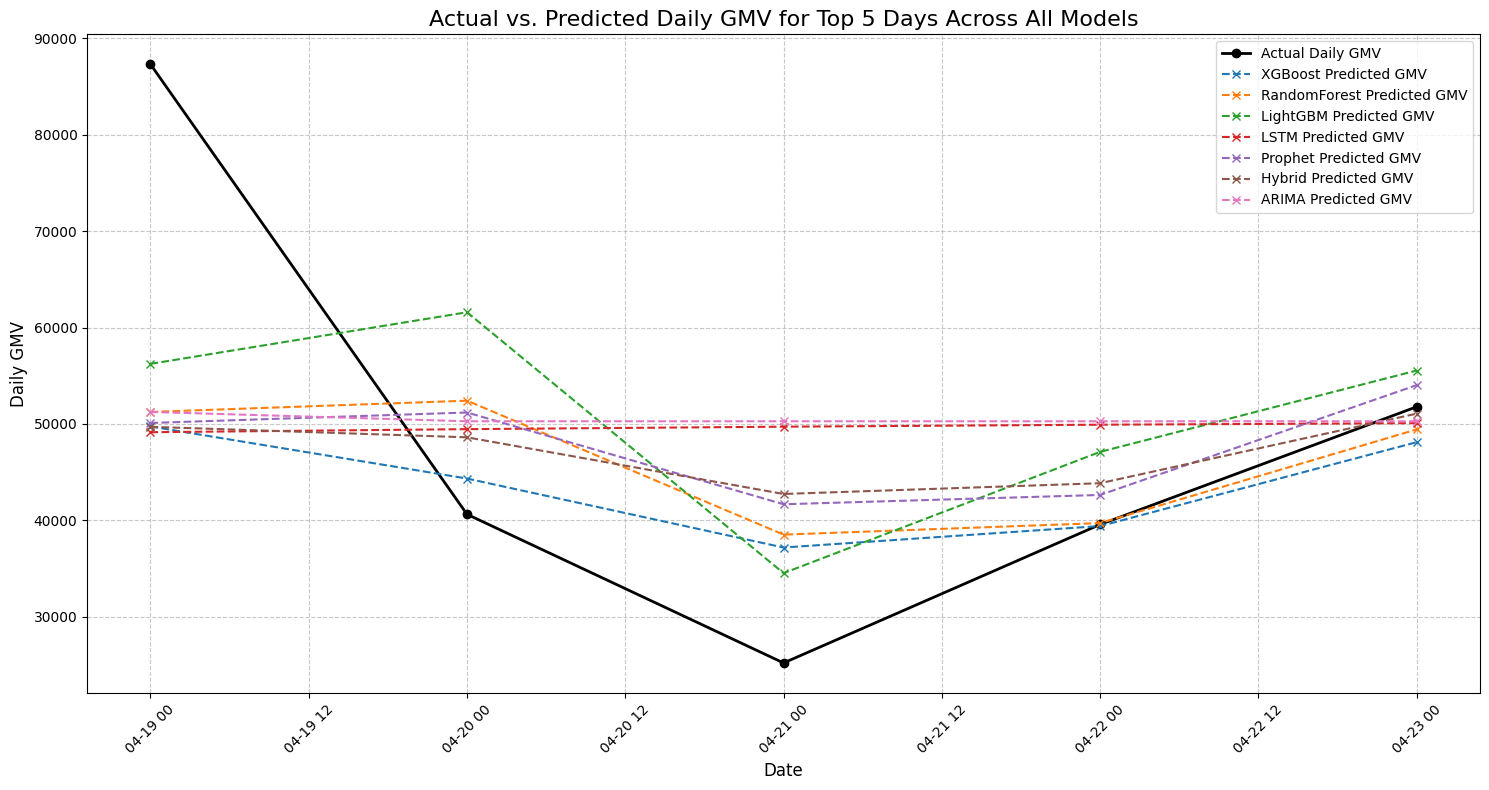

In [144]:
plt.figure(figsize=(15, 8))
plt.plot(prediction_df['date'].head(5), prediction_df['daily_gmv'].head(5), label='Actual Daily GMV', marker='o', linewidth=2, color='black')

for col in prediction_df.columns:
    if col not in ['date', 'daily_gmv']:
        plt.plot(prediction_df['date'].head(5), prediction_df[col].head(5), label=f'{col} Predicted GMV', marker='x', linestyle='--')

plt.title('Actual vs. Predicted Daily GMV for Top 5 Days Across All Models', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily GMV', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The following plot visualizes the 113-day(test data) holdout forecasts for all seven models alongside the actual daily GMV. This allows for a comprehensive comparison of how each model performs over the entire prediction period.

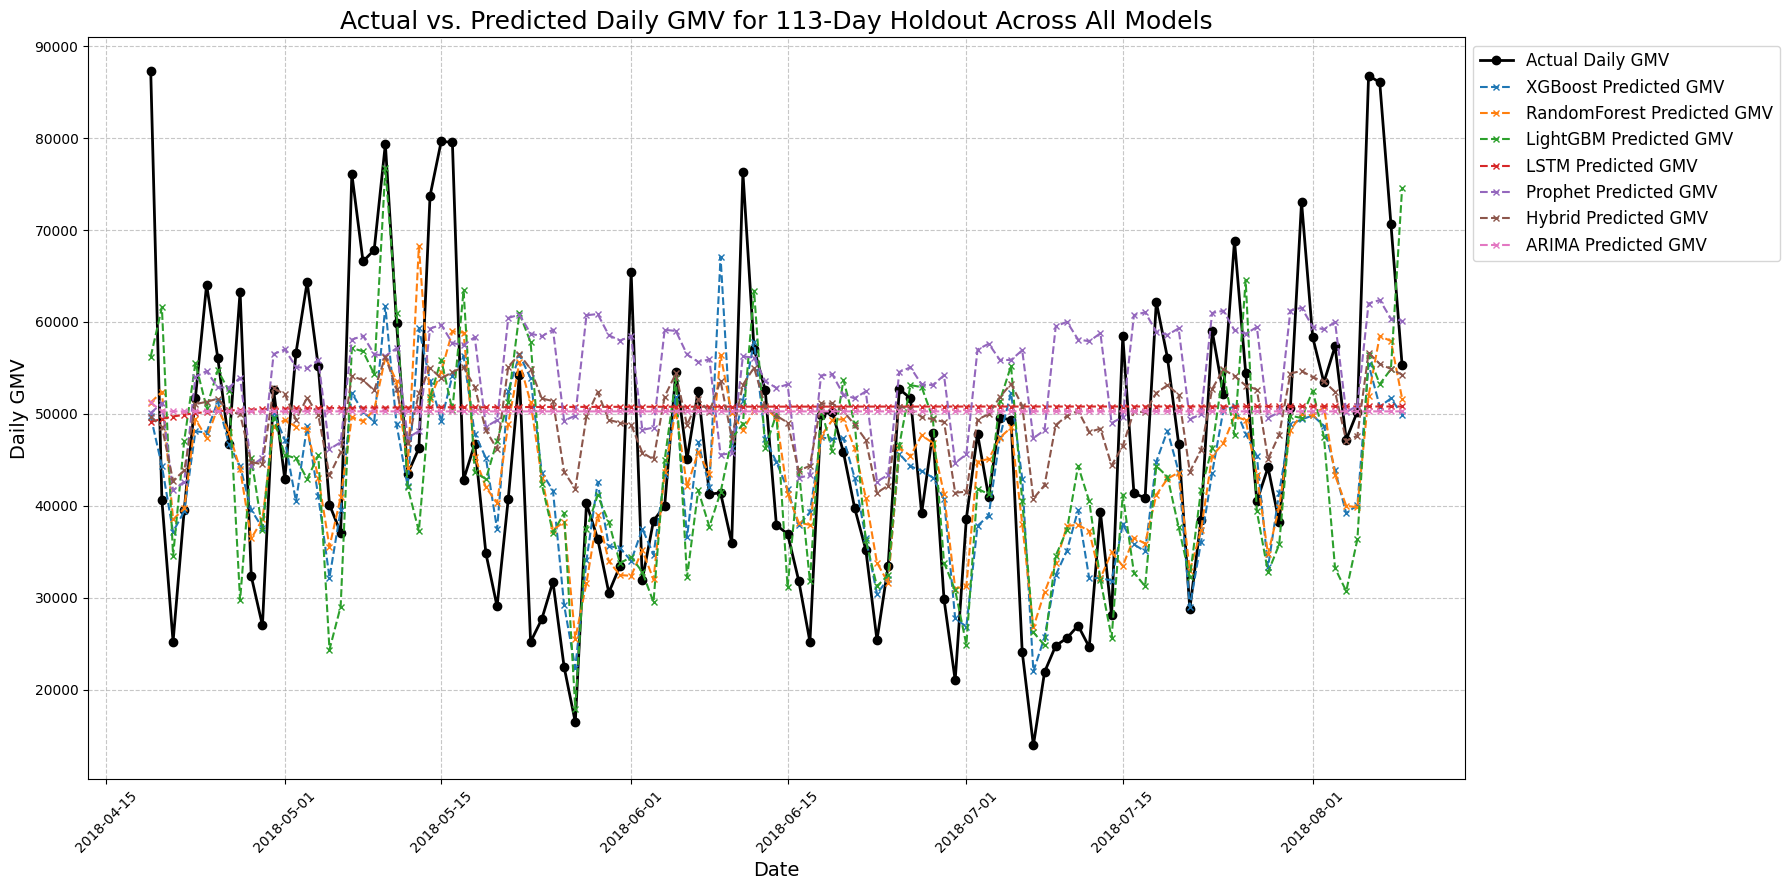

In [145]:
plt.figure(figsize=(18, 9))
plt.plot(prediction_df['date'], prediction_df['daily_gmv'], label='Actual Daily GMV', marker='o', linewidth=2, color='black')

for col in prediction_df.columns:
    if col not in ['date', 'daily_gmv']:
        plt.plot(prediction_df['date'], prediction_df[col], label=f'{col} Predicted GMV', linestyle='--', marker='x', markersize=5)

plt.title('Actual vs. Predicted Daily GMV for 113-Day Holdout Across All Models', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Daily GMV', fontsize=14)
plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [146]:
 # Evaluation storage
evaluation_rows = []
# Helper function to calculate SMAPE
def smape(y_true, y_pred):
    # Ensure y_true and y_pred are numpy arrays for consistent operations
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100.0 / len(y_true) * np.sum(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9))
def evaluate_model(model_name, y_true, y_pred):
    # Ensure y_true and y_pred are numpy arrays
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Clip values for RMSLE to avoid log of zero or negative numbers
    y_true_clip = np.clip(y_true, 0, None)
    y_pred_clip = np.clip(y_pred, 0, None)

    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100.0
    smape_val = smape(y_true, y_pred) # Call the helper smape function
    r2 = r2_score(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_true_clip, y_pred_clip))

    evaluation_rows.append({
        "Model": model_name,
        "WAPE":np.round(wape, 2),
        "SMAPE": np.round(smape_val, 2),
        "MAE": np.round(mae, 2),
        "RMSLE":np.round(rmsle,2),
        "RMSE": np.round(rmse, 2),
        "R2": np.round(r2, 4)

    })

# Populate evaluation_rows by calling evaluate_model for each prediction
# y_test_ml and predictions_store are available from previous cells.
for model_name, predictions in predictions_store.items():
    evaluate_model(model_name, y_test_ml, predictions)

# Leaderboard Table
eval_df = pd.DataFrame(evaluation_rows)

eval_df = eval_df.sort_values("RMSE").reset_index(drop=True)

eval_df["Rank"] = np.arange(1, len(eval_df) + 1)

eval_df = eval_df[
    ["Rank", "Model", "WAPE", "SMAPE", "MAE", "RMSLE", "RMSE", "R2"]
]

display(eval_df)

,Rank,Model,WAPE,SMAPE,MAE,RMSLE,RMSE,R2
0,1,XGBoost,21.06,21.26,9750.13,0.26,12766.63,0.3753
1,2,RandomForest,21.42,21.94,9915.67,0.27,12781.79,0.3739
2,3,LightGBM,22.76,23.45,10534.99,0.30,13445.02,0.3072
3,4,Hybrid,24.91,25.81,11529.76,0.34,14294.80,0.2168
4,5,Prophet,29.27,29.42,13549.21,0.40,16561.97,-0.0513
5,6,ARIMA,29.34,29.81,13582.24,0.39,16620.33,-0.0587
6,7,LSTM,29.65,30.07,13725.60,0.40,16782.65,-0.0795


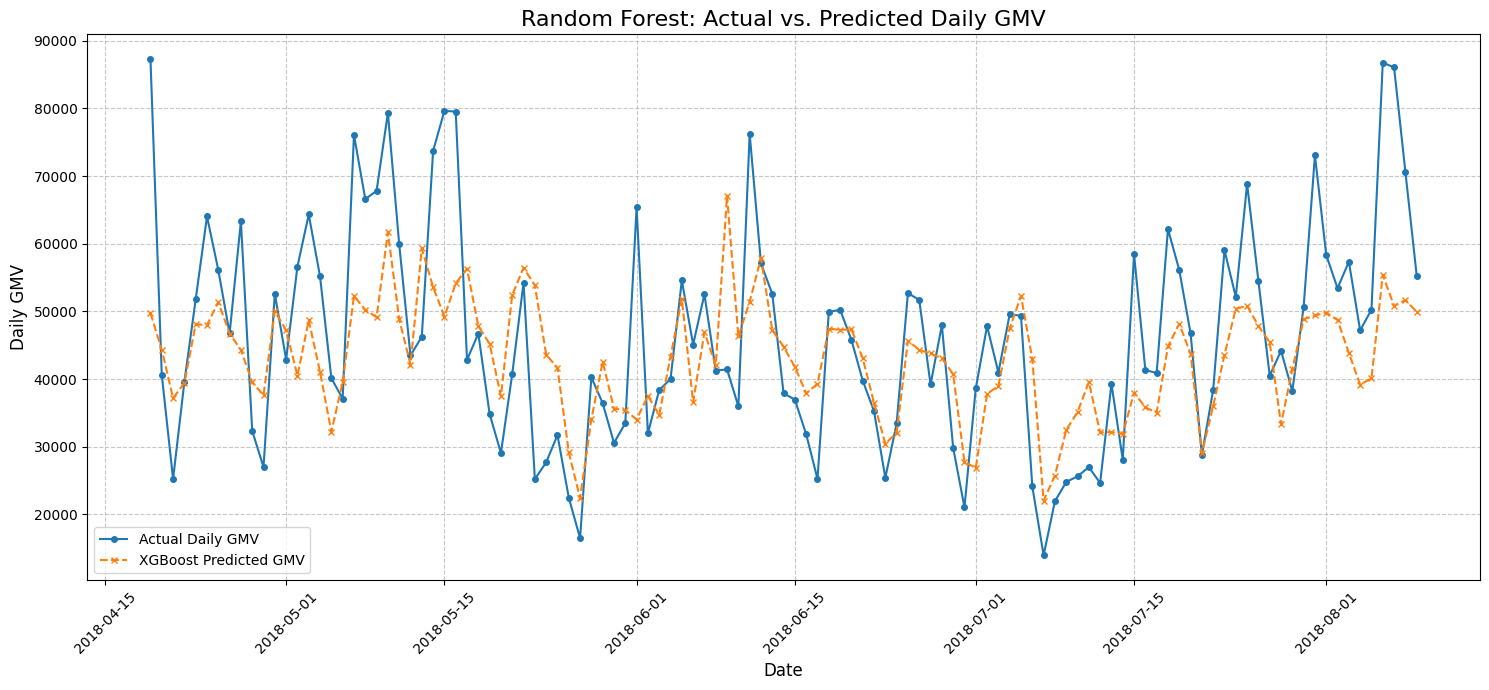

In [147]:
plt.figure(figsize=(15, 7))
plt.plot(test_df['date'], y_test_ml, label='Actual Daily GMV', marker='o', linestyle='-', markersize=4)
plt.plot(test_df['date'], predictions_store['XGBoost'], label='XGBoost Predicted GMV', marker='x', linestyle='--', markersize=4)

plt.title('XGBoost: Actual vs. Predicted Daily GMV', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily GMV', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

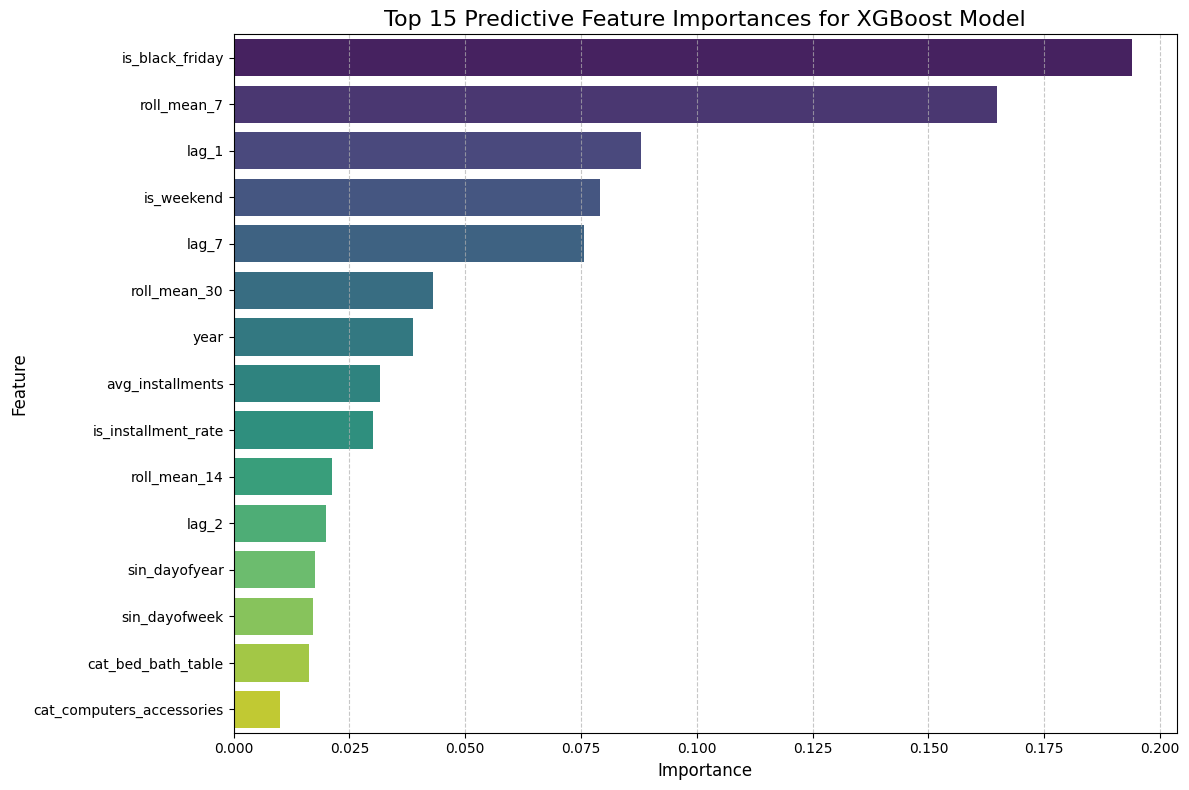

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the XGBoost model
xgb_model = trained_models["XGBoost"]

# Get feature importances and feature names
feature_importances = xgb_model.feature_importances_
feature_names = X_train_ml.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort by importance in descending order and select top 15
top_15_features = importance_df.sort_values(by='Importance', ascending=False).head(15)

# Create the visualization
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_15_features, palette='viridis')
plt.title('Top 15 Predictive Feature Importances for XGBoost Model', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Generating 90-day forecasts for all models...


,date,XGBoost,RandomForest,LightGBM,Prophet,LSTM,ARIMA,Hybrid
0,2018-08-10,41726.820312,47060.434790,60474.187324,60969.212433,49143.410156,51245.820744,51648.755286
1,2018-08-11,39433.226562,43098.074180,60390.041475,51206.656017,49461.125000,50279.453101,47150.969047
2,2018-08-12,40105.000000,43979.083139,60648.207360,51920.221369,49716.562500,50279.453101,47714.558274
3,2018-08-13,48948.671875,52932.508931,66285.736299,63057.278399,49920.964844,50279.453101,54883.803938
4,2018-08-14,46937.917969,52982.287322,64367.430111,63454.505272,50081.796875,50279.453101,54487.718124


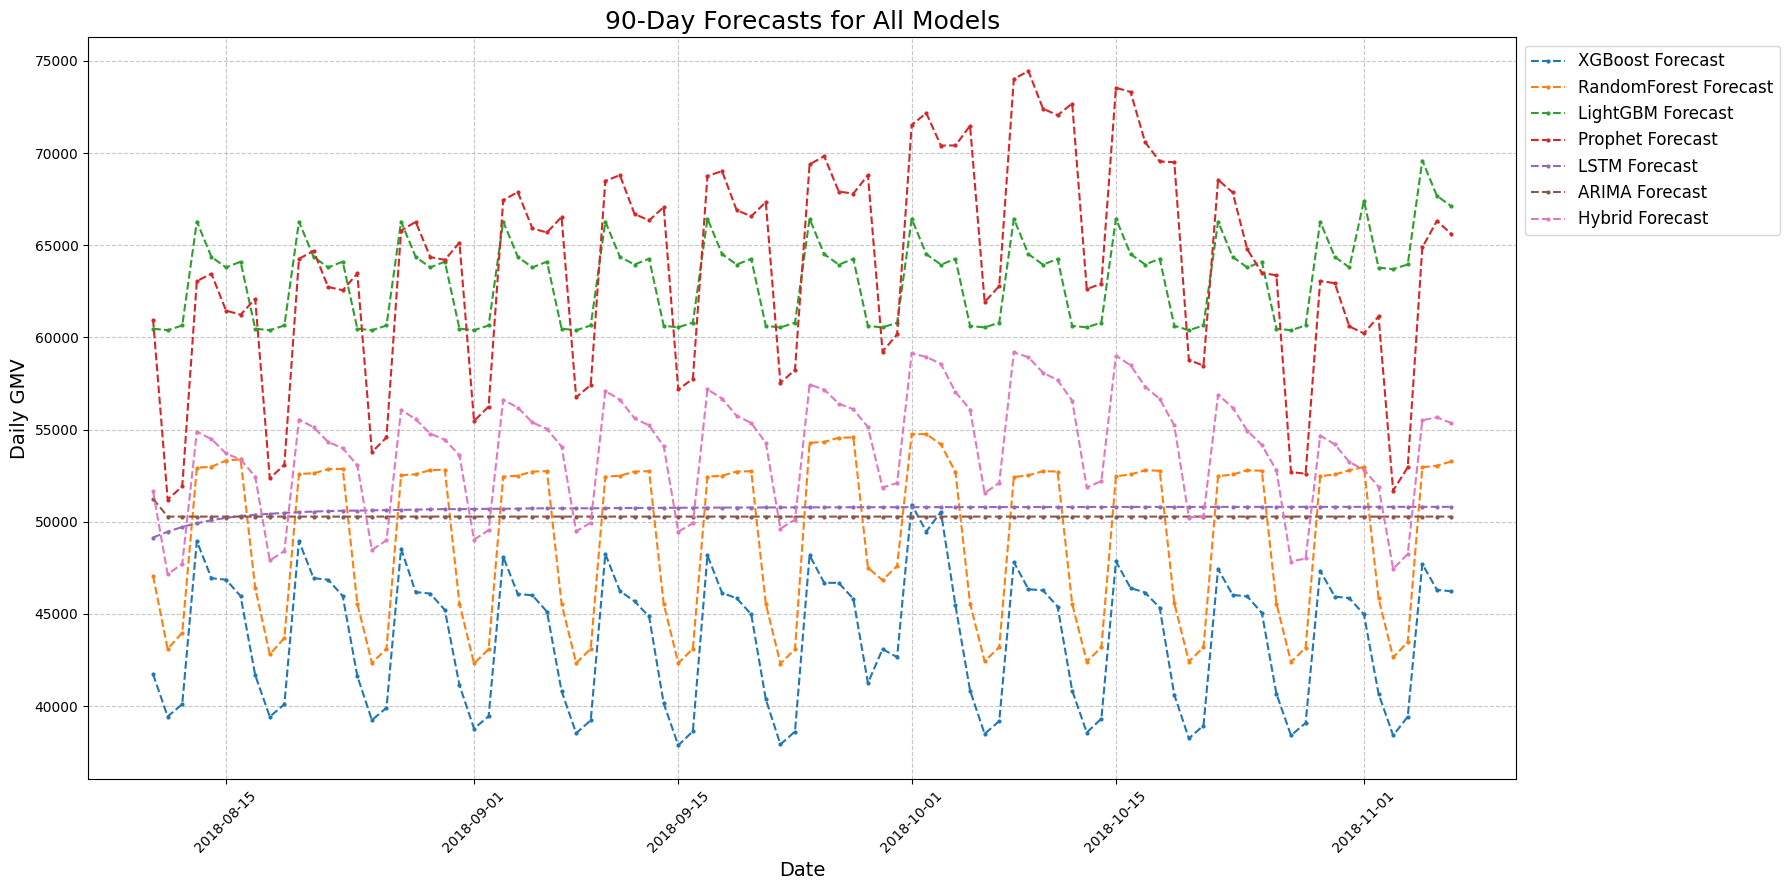

In [149]:
print('Generating 90-day forecasts for all models...')

# Extend the future DataFrame for Prophet to cover 90 days
last_date = daily_ts['date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=90, freq='D')
future_df = pd.DataFrame({'ds': future_dates})

# Prepare feature columns for the future_df
# This requires re-creating the feature engineering steps for future dates
# First, create an empty DataFrame to store the future features
future_features = pd.DataFrame(index=future_dates)
future_features.index.name = 'date'
future_features = future_features.reset_index()

# Add time-based features to future_features
future_features['year'] = future_features['date'].dt.year
future_features['month'] = future_features['date'].dt.month
future_features['quarter'] = future_features['date'].dt.quarter
future_features['dayofweek'] = future_features['date'].dt.dayofweek
future_features['dayofyear'] = future_features['date'].dt.dayofyear
future_features['week'] = future_features['date'].dt.isocalendar().week
future_features['hour'] = 12 # Assume a neutral hour for future predictions if not specific
future_features['is_weekend'] = future_features['dayofweek'].isin([5, 6]).astype(int)

# Cyclic Fourier Encoding (using the same encoder from training)
# The encoder needs to be called on a DataFrame similar to df_new, then aggregated
# For simplicity, we will apply Fourier terms directly to future_features for now.
# In a real-world scenario, you might have to reconstruct all features for future dates.
future_features['sin_dayofweek'] = np.sin(2 * np.pi * future_features['dayofweek'] / 7.0)
future_features['cos_dayofweek'] = np.cos(2 * np.pi * future_features['dayofweek'] / 7.0)
future_features['sin_week'] = np.sin(2 * np.pi * future_features['week'] / 52.0)
future_features['cos_week'] = np.cos(2 * np.pi * future_features['week'] / 52.0)
future_features['sin_month'] = np.sin(2 * np.pi * future_features['month'] / 12.0)
future_features['cos_month'] = np.cos(2 * np.pi * future_features['month'] / 12.0)
future_features['sin_dayofyear'] = np.sin(2 * np.pi * future_features['dayofyear'] / 365)
future_features['cos_dayofyear'] = np.cos(2 * np.pi * future_features['dayofyear'] / 365)

# Placeholder for other features. For a full forecast, these would need to be projected.
# For now, we'll use the last known values or zeros/means where appropriate for demonstration.
for col in X_train_ml.columns:
    if col not in future_features.columns and not col.startswith(('lag_', 'roll_')):
        if 'avg_price' in col or 'avg_freight_pct' in col or 'avg_installments' in col or 'is_installment_rate' in col or 'is_returning_customer' in col:
            future_features[col] = X_train_ml[col].iloc[-1] # Use last known value
        elif col.startswith('cat_') or col.startswith('state_'):
            future_features[col] = 0 # Assume 0 for one-hot encoded categories/states for simplicity
        else:
            future_features[col] = X_train_ml[col].mean() # Use mean for others

# Add Black Friday and Holiday indicator flags
future_features['is_black_friday'] = ((future_features['month'] == 11) & (future_features['date'].dt.day >= 22)).astype(int)
future_features['is_holiday_season'] = ((future_features['month'] == 12) & (future_features['date'].dt.day <= 24)).astype(int)

# For lag and rolling window features, we need an iterative approach
# Initialize with the last known values from train_df or test_df for the first forecast day
# and then update iteratively.

# Create a DataFrame to hold the 90-day forecast predictions
forecast_90_days_df = pd.DataFrame({'date': future_dates})

# --- Predict for XGBoost, RandomForest, LightGBM, and Hybrid ---
for model_name in ['XGBoost', 'RandomForest', 'LightGBM']:
    model = trained_models[model_name]
    # For tree-based models, we need lagged features. This is a simplified approach.
    # In a production system, this would involve an iterative prediction with feature updates.
    # For this exercise, we'll make a direct prediction for all 90 days. This might not be
    # accurate for models heavily relying on lagged targets without iterative updates.
    # To properly handle lags for future predictions, a loop is needed where each prediction
    # becomes the input for the next lag.

    # For demonstration purposes, we will fill `lag` and `roll` features using the last values from `X_train_ml`
    # and assume they stay constant, which is a simplification for non-iterative forecasting.
    X_future = future_features.copy()
    for lag_col in [c for c in X_train_ml.columns if c.startswith(('lag_', 'roll_'))]:
        X_future[lag_col] = X_train_ml[lag_col].iloc[-1]

    predictions_store[f'{model_name}_90_days'] = model.predict(X_future[feature_cols])
    forecast_90_days_df[model_name] = predictions_store[f'{model_name}_90_days']

# --- Predict for Prophet ---
prophet_forecast_future = m_prophet.predict(future_df)
predictions_store['Prophet_90_days'] = prophet_forecast_future['yhat'].values
forecast_90_days_df['Prophet'] = predictions_store['Prophet_90_days']

# --- Predict for LSTM (iterative forecasting needed) ---
lstm_90_days_preds = []
current_seq_lstm = train_scaled[-SEQ_LENGTH:].copy() # Get the last sequence from training data

for _ in range(90):
    pred = lstm_model.predict(current_seq_lstm.reshape(1, SEQ_LENGTH, 1), verbose=0)
    lstm_90_days_preds.append(pred[0,0])
    current_seq_lstm = np.append(current_seq_lstm[1:], pred).reshape(SEQ_LENGTH, 1)

predictions_store['LSTM_90_days'] = scaler.inverse_transform(np.array(lstm_90_days_preds).reshape(-1, 1)).flatten()
forecast_90_days_df['LSTM'] = predictions_store['LSTM_90_days']

# --- Predict for ARIMA ---
arima_90_days_forecast = stepwise_model.predict(n_periods=90)
predictions_store['ARIMA_90_days'] = arima_90_days_forecast.values
forecast_90_days_df['ARIMA'] = predictions_store['ARIMA_90_days']

# --- Predict for Hybrid (using already generated 90-day forecasts) ---
predictions_store["Hybrid_90_days"] = (
    0.40 * predictions_store["Prophet_90_days"] +
    0.30 * predictions_store["LSTM_90_days"] +
    0.30 * predictions_store["XGBoost_90_days"]
)
forecast_90_days_df['Hybrid'] = predictions_store['Hybrid_90_days']


display(forecast_90_days_df.head())

# Create a visualization for the 90-day forecasts
plt.figure(figsize=(18, 9))
for col in forecast_90_days_df.columns:
    if col != 'date':
        plt.plot(forecast_90_days_df['date'], forecast_90_days_df[col], label=f'{col} Forecast', linestyle='--', marker='.', markersize=4)

plt.title('90-Day Forecasts for All Models', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Daily GMV', fontsize=14)
plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


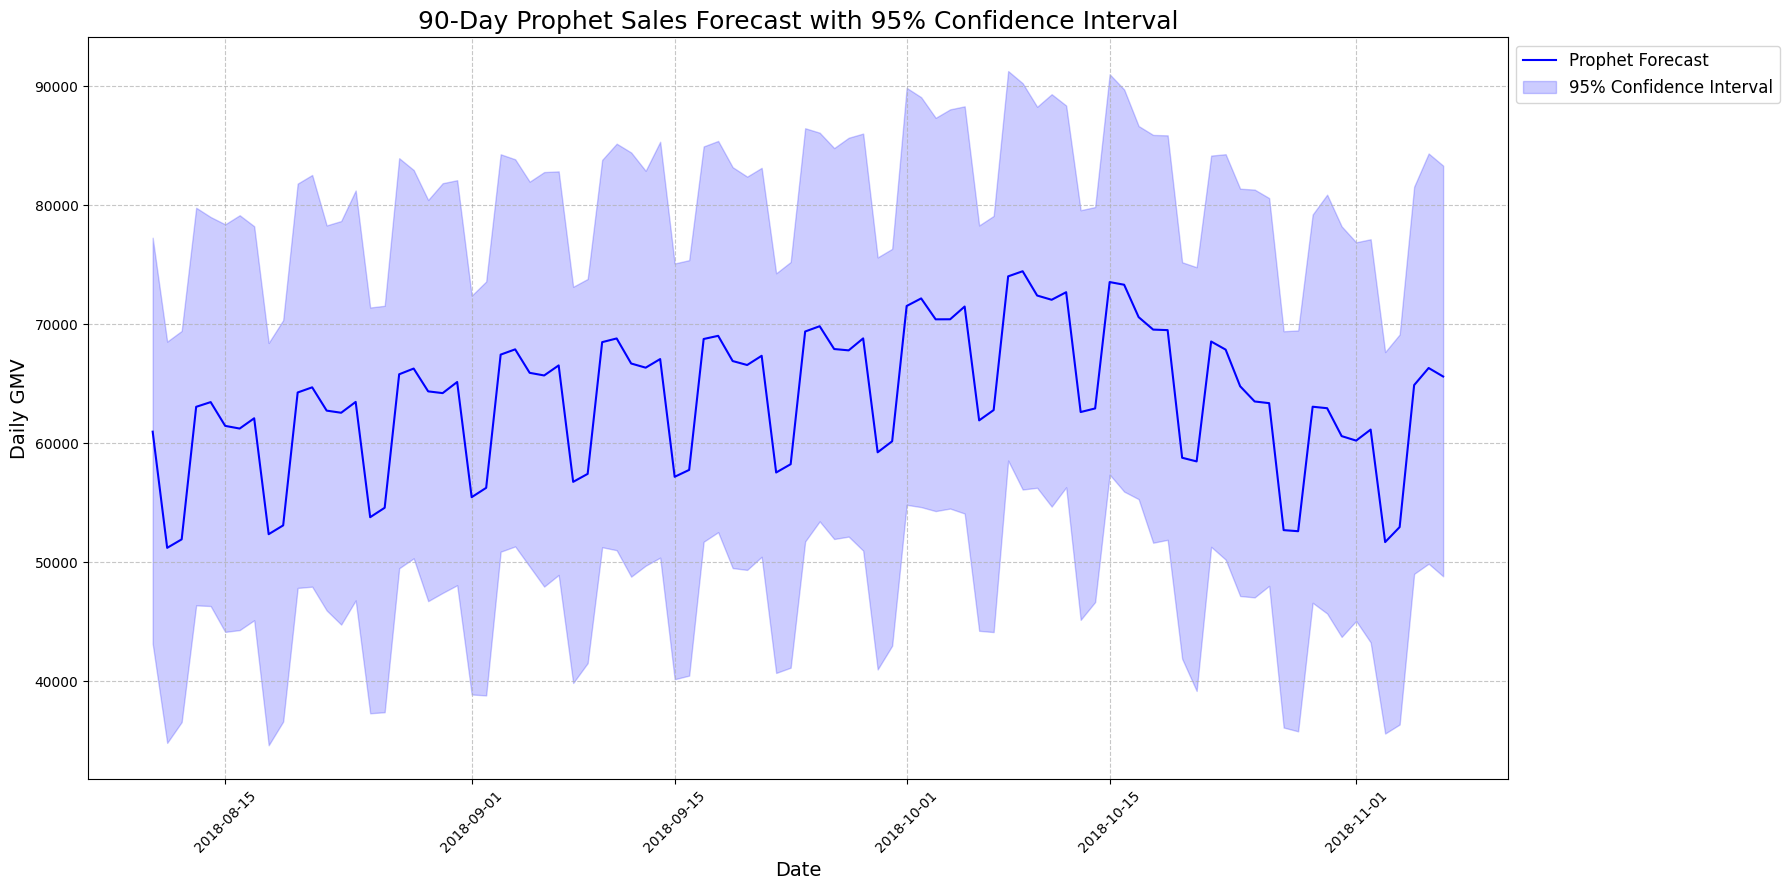

In [150]:
plt.figure(figsize=(18, 9))
plt.plot(future_df['ds'], prophet_forecast_future['yhat'], label='Prophet Forecast', color='blue')
plt.fill_between(future_df['ds'], prophet_forecast_future['yhat_lower'], prophet_forecast_future['yhat_upper'], color='blue', alpha=0.2, label='95% Confidence Interval')

plt.title('90-Day Prophet Sales Forecast with 95% Confidence Interval', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Daily GMV', fontsize=14)
plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Black Friday and Holiday Sales Future Forecasts

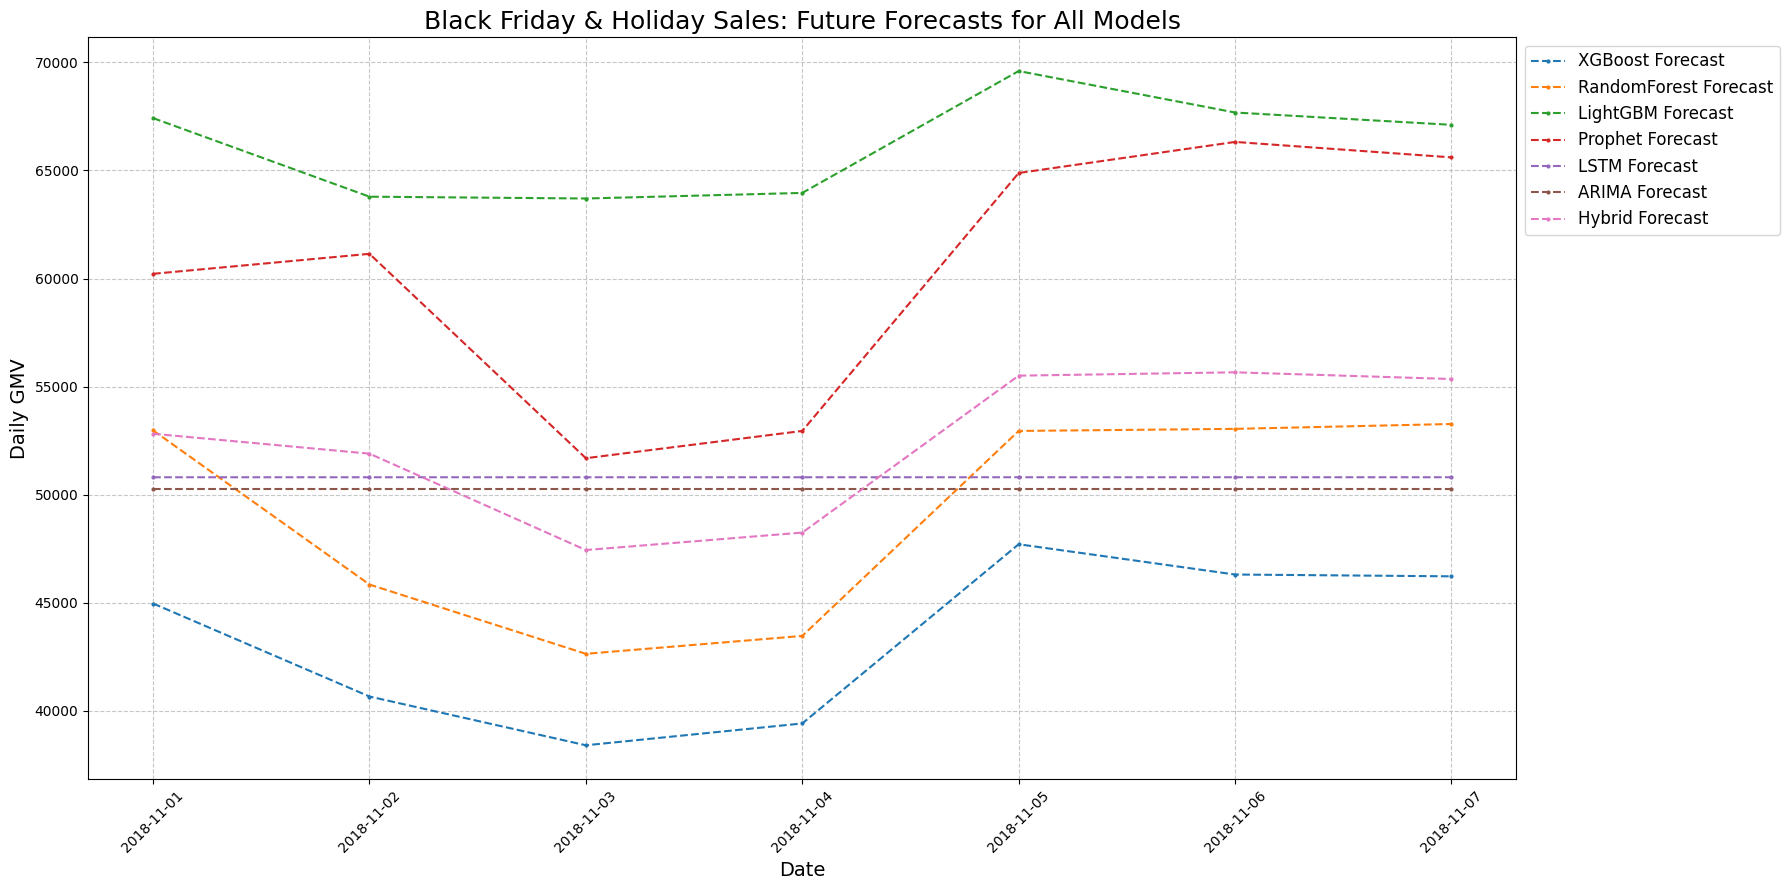

In [151]:
# Filter the 90-day forecast DataFrame for Black Friday and Holiday sales period (November and December)
black_friday_holiday_forecast = forecast_90_days_df[
    (forecast_90_days_df['date'].dt.month == 11) |
    (forecast_90_days_df['date'].dt.month == 12)
].copy()

# Create a visualization for the filtered Black Friday and Holiday sales forecasts
plt.figure(figsize=(18, 9))
for col in black_friday_holiday_forecast.columns:
    if col != 'date':
        plt.plot(
            black_friday_holiday_forecast['date'],
            black_friday_holiday_forecast[col],
            label=f'{col} Forecast',
            linestyle='--',
            marker='.',
            markersize=4
        )

plt.title('Black Friday & Holiday Sales: Future Forecasts for All Models', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Daily GMV', fontsize=14)
plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Fine tuning for the best model XGBoost

In [152]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit


# Define the parameter space for RandomizedSearchCV
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 400, 500],           # Number of boosting rounds
    'max_depth': [3, 4, 5, 6, 8, 10],                    # Maximum tree depth
    'learning_rate': [0.01, 0.02, 0.05, 0.08, 0.1],      # Step size shrinkage
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],              # Row sampling per tree
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],       # Column sampling per tree
    'min_child_weight': [1, 3, 5, 7],                    # Minimum sum of instance weight in a child
    'gamma': [0, 0.1, 0.2, 0.3, 0.5],                    # Minimum loss reduction to split further
    'reg_alpha': [0, 0.01, 0.1, 1, 10],                  # L1 regularization
    'reg_lambda': [0.5, 1, 1.5, 2, 5]                    # L2 regularization
}

# Initialize an XGBRegressor
xgb = XGBRegressor(random_state=42)

# Define TimeSeriesSplit for cross-validation (respects chronological order — no shuffling)
tscv = TimeSeriesSplit(n_splits=3)

# Initialize RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=50,   # Number of parameter settings sampled. Reduce for faster execution.
    cv=tscv,     # Use TimeSeriesSplit for cross-validation
    scoring='neg_mean_absolute_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Starting Randomized Search for XGBoost...")
random_search_xgb.fit(X_train_ml, y_train_ml)

print("Randomized Search complete.")
print(f"Best Parameters found: {random_search_xgb.best_params_}")
print(f"Best Score (cross-validation, neg MAE) found: {random_search_xgb.best_score_:.4f}")

# Get the best model
best_xgb_model = random_search_xgb.best_estimator_

# Store the best model
trained_models["XGBoost_Tuned"] = best_xgb_model

# Generate predictions with the best model
predictions_store["XGBoost_Tuned"] = best_xgb_model.predict(X_test_ml)

# Evaluate the fine-tuned model
evaluate_model("XGBoost_Tuned", y_test_ml, predictions_store["XGBoost_Tuned"])


Starting Randomized Search for XGBoost...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Randomized Search complete.
Best Parameters found: {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 10, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.08, 'gamma': 0.5, 'colsample_bytree': 0.9}
Best Score (cross-validation, neg MAE) found: -9418.7359


### Comparison of model with Tuned XGBoost and Actual

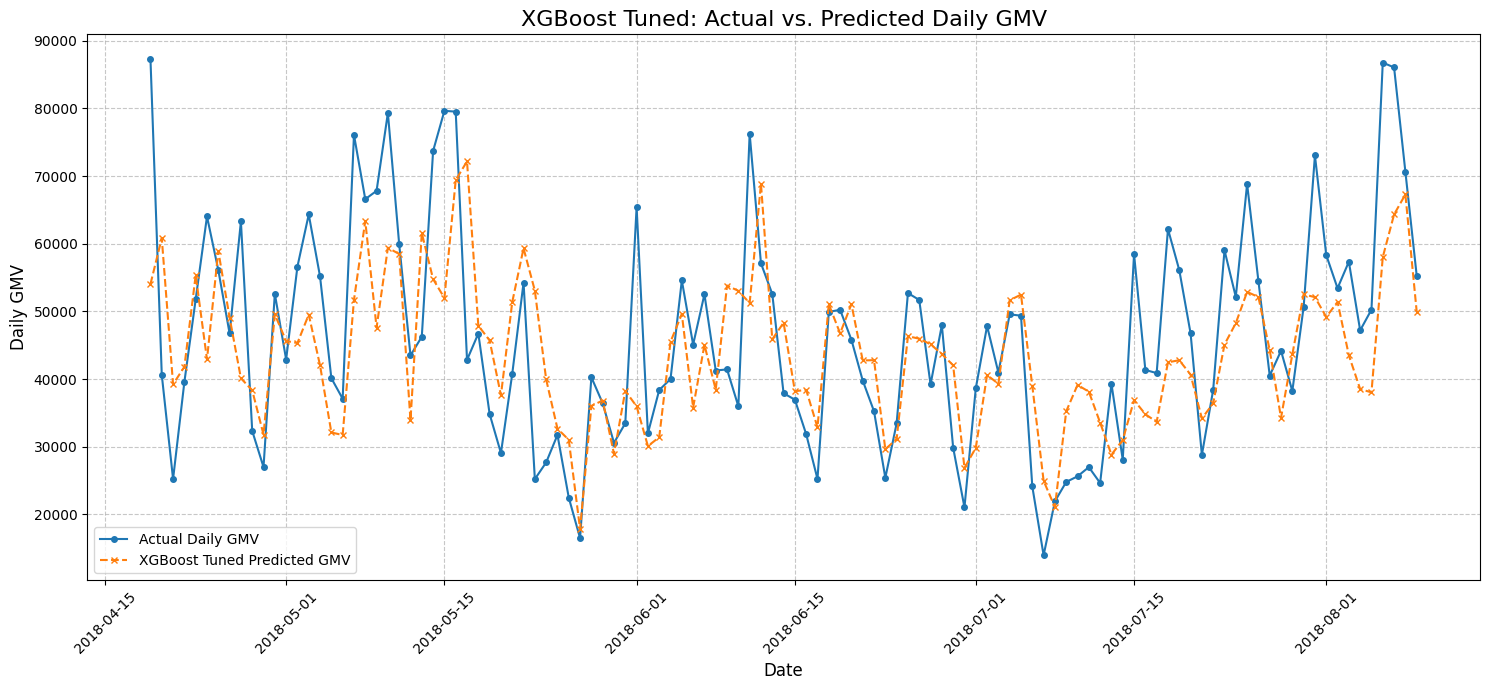

In [153]:
plt.figure(figsize=(15, 7))
plt.plot(test_df['date'], y_test_ml, label='Actual Daily GMV', marker='o', linestyle='-', markersize=4)
plt.plot(test_df['date'], predictions_store['XGBoost_Tuned'], label='XGBoost Tuned Predicted GMV', marker='x', linestyle='--', markersize=4)

plt.title('XGBoost Tuned: Actual vs. Predicted Daily GMV', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily GMV', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Black Friday and Holiday Sales Future Forecasts

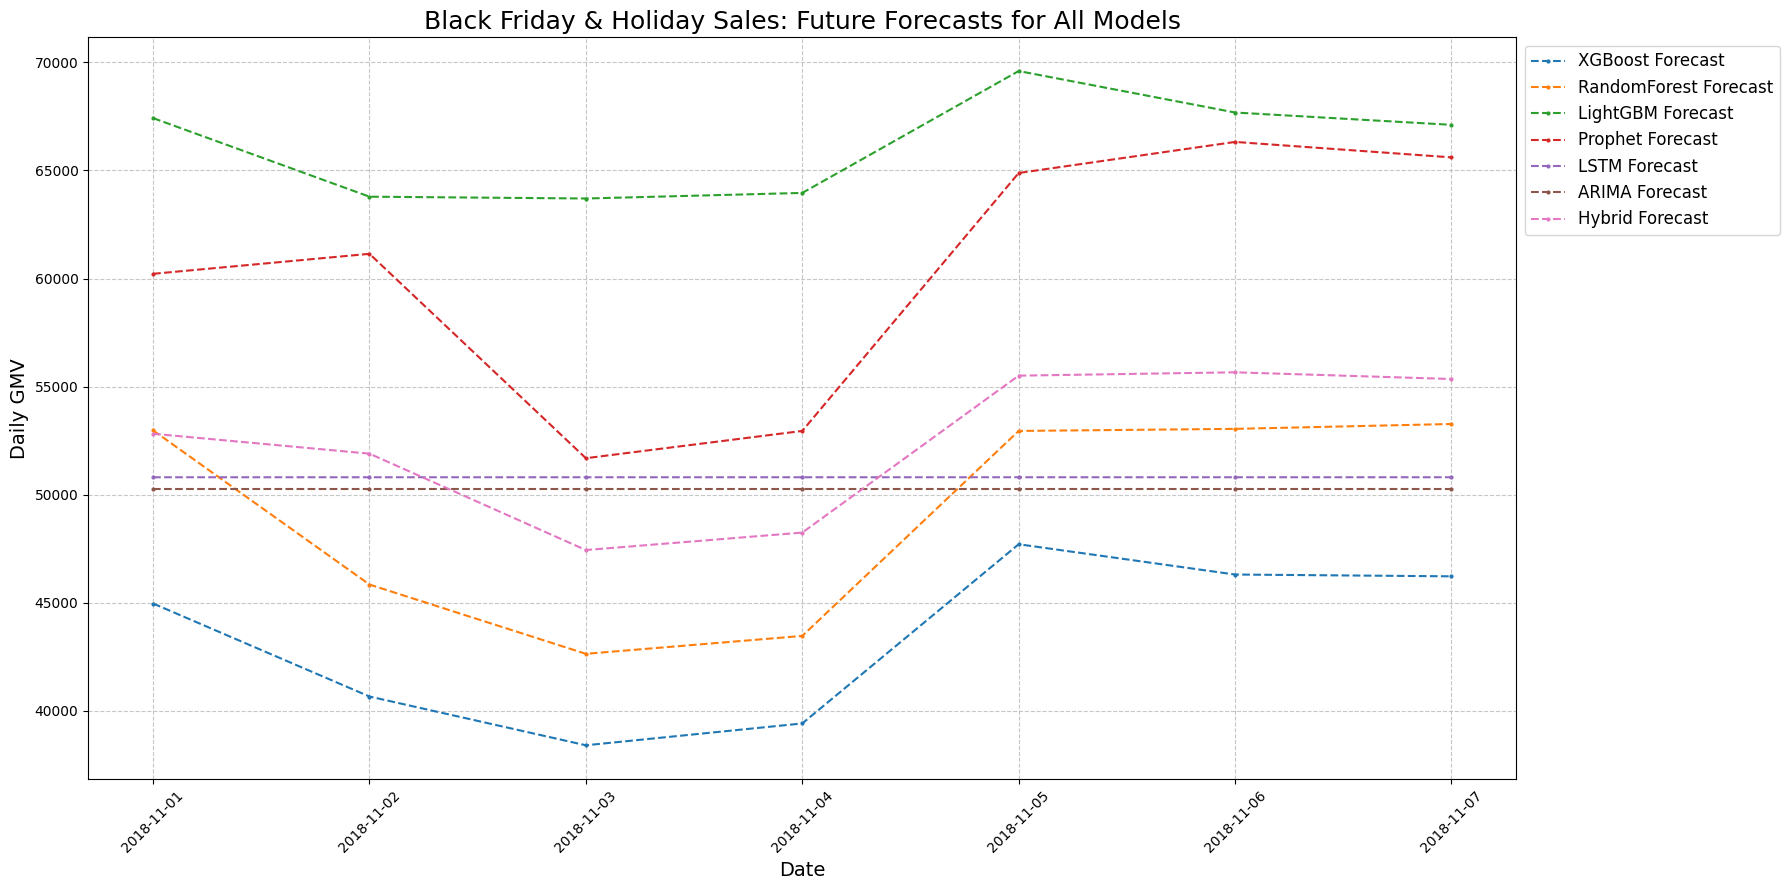

In [154]:
# Filter the 90-day forecast DataFrame for Black Friday and Holiday sales period (November and December)
black_friday_holiday_forecast = forecast_90_days_df[
    (forecast_90_days_df['date'].dt.month == 11) |
    (forecast_90_days_df['date'].dt.month == 12)
].copy()

# Create a visualization for the filtered Black Friday and Holiday sales forecasts
plt.figure(figsize=(18, 9))
for col in black_friday_holiday_forecast.columns:
    if col != 'date':
        plt.plot(
            black_friday_holiday_forecast['date'],
            black_friday_holiday_forecast[col],
            label=f'{col} Forecast',
            linestyle='--',
            marker='.',
            markersize=4
        )

plt.title('Black Friday & Holiday Sales: Future Forecasts for All Models', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Daily GMV', fontsize=14)
plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Tuned Random Forest and Random Forest  prediction models with Actuals and Error%

In [155]:
prediction_df["XGBoost_Tuned"] = predictions_store["XGBoost_Tuned"]
prediction_df["XGBoost"] = predictions_store["XGBoost"]

# Calculate Error % for the untuned XGBoost model
prediction_df['XGB_Error %'] = ((prediction_df['XGBoost'] - prediction_df['daily_gmv']) / prediction_df['daily_gmv']) * 100

# Calculate Error % for the tuned RandomForest_Tuned model
prediction_df['XGB_Tuned_Error %'] = ((prediction_df['XGBoost_Tuned'] - prediction_df['daily_gmv']) / prediction_df['daily_gmv']) * 100

# Select and display the desired columns from the updated prediction_df
display_df = prediction_df[['date', 'daily_gmv', 'XGBoost', 'XGB_Error %', 'XGBoost_Tuned', 'XGB_Tuned_Error %']].copy()

display(display_df.tail())

,date,daily_gmv,XGBoost,XGB_Error %,XGBoost_Tuned,XGB_Tuned_Error %
557,2018-08-05,50264.19,40107.898438,-20.205820,38039.433594,-24.321005
558,2018-08-06,86782.85,55392.726562,-36.170883,58026.960938,-33.135451
559,2018-08-07,86064.49,50807.464844,-40.965821,64331.621094,-25.251842
560,2018-08-08,70646.97,51682.765625,-26.843620,67294.562500,-4.745296
561,2018-08-09,55303.76,49932.750000,-9.711835,49974.160156,-9.636957


###So it is clearly showing that normal XGBoost model is predicting better than the tuned one.

In [156]:
# Define the file paths for pickling
pickle_dir = '/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/'

# Pickle df_new
with open(f'{pickle_dir}df_new.pkl', 'wb') as f:
    joblib.dump(df_new, f)
print('df_new pickled successfully.')

# Pickle rfm
with open(f'{pickle_dir}rfm.pkl', 'wb') as f:
    joblib.dump(rfm, f)
print('rfm pickled successfully.')

# Pickle the encoder object
with open(f'{pickle_dir}sales_feature_encoder.pkl', 'wb') as f:
    joblib.dump(encoder, f)
print('SalesFeatureEncoder pickled successfully.')

# Pickle the dictionary of trained models
with open(f'{pickle_dir}trained_forecasting_models.pkl', 'wb') as f:
    joblib.dump(trained_models, f)
print('Trained forecasting models pickled successfully.')

df_new pickled successfully.
rfm pickled successfully.
SalesFeatureEncoder pickled successfully.
Trained forecasting models pickled successfully.
